In [11]:
import statistics
import plotly.tools
import scipy.special
import mysql.connector
from dotenv import load_dotenv
import os
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta
import pandas.io.sql as sqlio
from sklearn.cluster import KMeans
from sklearn import preprocessing
import sklearn.cluster as cluster
import sklearn.metrics as metrics
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from matplotlib import pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import statistics
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from xgboost import plot_tree
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
import plotly.express as px
from matplotlib import font_manager
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.metrics import make_scorer, matthews_corrcoef
my_font = plt.rcParams['font.family'] = 'Liberation Serif'
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import matplotlib.pyplot as plt
from xgboost import plot_importance
import shap

# Add the Liberation Serif font explicitly
fm.fontManager.addfont('/usr/share/fonts/truetype/liberation/LiberationSerif-Regular.ttf')
fm.fontManager.addfont('/usr/share/fonts/truetype/liberation/LiberationSerif-Bold.ttf')
fm.fontManager.addfont('/usr/share/fonts/truetype/liberation/LiberationSerif-Italic.ttf')
fm.fontManager.addfont('/usr/share/fonts/truetype/liberation/LiberationSerif-BoldItalic.ttf')

# Now use it
plt.rcParams['font.family'] = 'Liberation Serif'

# Verify
print("Liberation Serif found:", 'Liberation Serif' in [f.name for f in fm.fontManager.ttflist])

Liberation Serif found: True


# Data Preprocessing

In [15]:
# 1. Open the connection to your port-forwarded database
connection = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

# 2. Write your SQL query to grab the Dryad data
query = "SELECT * FROM RawClassificationTreatment;"

# 3. Pull it straight into a Pandas DataFrame!
alldata = sqlio.read_sql(query, connection)

# 4. Close the connection
connection.close()

# Check out your data
print(df.head())

/tmp/ipykernel_2762/3543076885.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  alldata = sqlio.read_sql(query, connection)


   RawTreatmentID  PubID  ExperimentID  TreatmentID        Date    DOY  \
0               1      1             1            2  2006-06-19  170.0   
1               2      1             1            2  2006-06-20  171.0   
2               3      1             1            2  2006-06-21  172.0   
3               4      1             1            2  2006-06-22  173.0   
4               5      1             1            2  2006-06-23  174.0   

    N2OFlux  FluxStandardError  HMTruth  HMMCD  ... SandMean  SiltMean  \
0  -9.69777                NaN      0.0    0.0  ...     26.0      52.0   
1  43.61360                NaN      0.0    0.0  ...     26.0      52.0   
2  -4.27172                NaN      0.0    0.0  ...     26.0      52.0   
3  53.78540                NaN      0.0    0.0  ...     26.0      52.0   
4  23.54990                NaN      0.0    0.0  ...     26.0      52.0   

   ClayMean  Gracenet  MAP  MAT  Latitude  Longitude  \
0      22.0         0  0.0  0.0   42.4261   -76.2267  

In [16]:
# Merge the columns VWC and VWCcalculated
# print the count of WFPS
alldata['VWC'].fillna(alldata['VWCcalculated'], inplace=True)
alldata['WFPS'].fillna(alldata['WFPScalculated'], inplace=True)
# Drop the calculated columns
alldata = alldata.drop('VWCcalculated', axis=1)
alldata = alldata.drop('WFPScalculated', axis=1)
# If VWC > 1, divide by 100
alldata['VWC'] = alldata['VWC'].apply(lambda x: x / 100 if x > 1 else x)
# Create a Year column by converting the Date column to datetime
alldata['Year'] = pd.to_datetime(alldata['Date']).dt.year

# Create a Group column by concatenating ExperimentID and Year
alldata['Group'] = alldata['ExperimentID'].astype(str) + '_' + alldata['Year'].astype(str)
print(alldata.count())

/tmp/ipykernel_2762/3926235168.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  alldata['VWC'].fillna(alldata['VWCcalculated'], inplace=True)
/tmp/ipykernel_2762/3926235168.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method n

RawTreatmentID       252368
PubID                252368
ExperimentID         252368
TreatmentID          252368
Date                 252368
DOY                  210269
N2OFlux               47736
FluxStandardError      9280
HMTruth              150095
HMMCD                230895
HMMAD                234624
HMKNN                 22909
HMIQR                 23363
VWC                   29307
WFPS                  18763
SoilT                 44515
AirT                  19833
Precip               245327
NitrogenApplied      251489
NitrogenType         210358
AirTMax              175818
AirTMin              175516
PrimaryCrop          252368
Management           252368
SandMean             246163
SiltMean             246163
ClayMean             246163
Gracenet             252368
MAP                  242201
MAT                  231090
Latitude             252368
Longitude            252368
PubTitle             252368
Citation             252368
Year                 252368
Group               

In [ ]:
# Linear Interpolate the VWC and SoilT and AirT columns for each TreatmentID as long as measurement
# gaps are less than 14 days. If the measurement gap is greater than 14 days, then set VWC and
# SoilT to None
import math
alldata['VWC'] = alldata['VWC'].astype(float)
alldata['SoilT'] = alldata['SoilT'].astype(float)
alldata['AirT'] = alldata['AirT'].astype(float)
alldata['WFPS'] = alldata['WFPS'].astype(float)
# Create separate interpolated columns for VWC, SoilT, and AirT
alldata['VWC_interpolated'] = alldata['VWC']
alldata['SoilT_interpolated'] = alldata['SoilT']
alldata['AirT_interpolated'] = alldata['AirT']
alldata['WFPS_interpolated'] = alldata['WFPS']
alldata['VWC_days_since_last_measurement'] = None
alldata['VWC_days_until_next_measurement'] = None

# Iterate through each TreatmentID and interpolate the VWC, SoilT, and AirT columns
for treatment in alldata['TreatmentID'].unique():
    treatment_df = alldata[alldata['TreatmentID'] == treatment]
    treatment_df['VWC_interpolated'] = treatment_df['VWC_interpolated'].interpolate(limit_direction='both', limit=7, limit_area='inside')
    treatment_df['SoilT_interpolated'] = treatment_df['SoilT_interpolated'].interpolate(limit_direction='both', limit=7, limit_area='inside')
    treatment_df['AirT_interpolated'] = treatment_df['AirT_interpolated'].interpolate(limit_direction='both', limit=7, limit_area='inside')
    treatment_df['WFPS_interpolated'] = treatment_df['WFPS_interpolated'].interpolate(limit_direction='both', limit=7, limit_area='inside')
    # Iterate through each row and calculate the number of days since the last row where VWC was not None
    i = 0
    for index, row in treatment_df.iterrows():
        # If vwc is nan, set it to None
        if row['VWC'] == '' or row['VWC'] == None or math.isnan(row['VWC']):
            i += 1
            treatment_df.at[index, 'VWC_days_since_last_measurement'] = i
        else:
            i = 0
            treatment_df.at[index, 'VWC_days_since_last_measurement'] = i

    # Iterate through each row and calculate the number of days until the next row where VWC was not None
    i = 0
    # Start by iterating through rows in reverse
    # reverse the rows of the treatment_df
    treatment_df = treatment_df.iloc[::-1]
    for index, row in treatment_df.iterrows():
        if row['VWC'] == '' or row['VWC'] == None or math.isnan(row['VWC']):
            i += 1
            treatment_df.at[index, 'VWC_days_until_next_measurement'] = i
        else:
            i = 0
            treatment_df.at[index, 'VWC_days_until_next_measurement'] = i

    # reverse the rows of the treatment_df
    treatment_df = treatment_df.iloc[::-1]
    alldata[alldata['TreatmentID'] == treatment] = treatment_df

alldata['VWC'] = alldata['VWC_interpolated']
alldata['WFPS'] = alldata['WFPS_interpolated']
alldata['SoilT'] = alldata['SoilT_interpolated']
alldata['AirT'] = alldata['AirT_interpolated']
alldata['VWC_days_since_last_measurement'] = alldata['VWC_days_since_last_measurement'].astype(int)
alldata['VWC_days_until_next_measurement'] = alldata['VWC_days_until_next_measurement'].astype(int)
alldata = alldata.drop('VWC_interpolated', axis=1)
alldata = alldata.drop('WFPS_interpolated', axis=1)
alldata = alldata.drop('SoilT_interpolated', axis=1)
alldata = alldata.drop('AirT_interpolated', axis=1)

print(alldata.count())
# Save to csv
alldata.to_csv('alldata_tracker.csv', index=False)


/tmp/ipykernel_1584/2580720655.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1584/2580720655.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1584/2580720655.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1

RawID                              206954
PubID                              206954
ExperimentID                       206954
TreatmentID                        206954
Date                               206954
DOY                                206954
N2OFlux                             22706
FluxStandardError                    9280
HMTruth                            148608
HMMCD                              203225
HMMAD                              206954
HMKNN                               22234
HMIQR                               22688
VWC                                 95099
WFPS                                53534
SoilT                              103523
AirT                                76375
Precip                             199913
NitrogenApplied                    206153
NitrogenType                       206954
AirTMax                            160847
AirTMin                            160557
PrimaryCrop                        206954
Management                        

In [ ]:
# Feature engineering: create a new column 'days_since_precip' that 
# tracks the number of days since the last precipitation event, and a column 'last_precip' that
# records the amount of the last precipitation event

experiments = pd.unique(alldata.TreatmentID)
alldata['days_since_precip'] = 0
alldata['last_precip'] = None
days_since_p_list = []
last_p_list = []
for experiment in experiments:
    expdf = alldata.query('TreatmentID == @experiment')
    first_flag = 1
    for index, row in expdf.iterrows():
        if row['Precip'] > 0:
            expdf.loc[index, "days_since_precip"] = 0
            expdf.loc[index, "last_precip"] = row['Precip']
            last_precip = row['Precip']
        elif first_flag == 1:
            expdf.loc[index, "days_since_precip"] = None
        elif past_days == None:
            expdf.loc[index, "days_since_precip"] = None
        elif row.Precip == 0:
            expdf.loc[index, "days_since_precip"] = past_days + 1
            expdf.loc[index, "last_precip"] = last_precip
        past_days = expdf.loc[index, "days_since_precip"]
        first_flag = 0
    days_since_p_list.extend(list(expdf.days_since_precip))
    last_p_list.extend(list(expdf.last_precip))
alldata['days_since_precip'] = days_since_p_list
alldata['last_precip'] = last_p_list

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
137
138
139
140
141
142
143
144
145
146
147
149
150
151
152
153
154
155
156
157
158
159
160
161
162
164
166
167
169
170
171
180
181
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
270
273
276
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
302
303
305
306
307
308
309
310
311
312
313
314
315
316
317
330
331
332
318
319
333
334
320
321
322
323
324
328
329


In [ ]:
# Feature engineering: create a new column 'days_since_fert' that 
# tracks the number of days since the last fertilization event, and a column 'last_fert' that
# records the amount of the last fertilization event, and a column 'last_fert_type' that 
# records the type of the last fertilization event

experiments = pd.unique(alldata.TreatmentID)
alldata['days_since_fert'] = 0
alldata['last_fert'] = None
alldata['last_fert_type'] = None
days_since_f_list = []
last_f_list = []
last_type_list = []
for experiment in experiments:
    expdf = alldata.query('TreatmentID == @experiment')
    first_flag = 1
    for index, row in expdf.iterrows():
        if row['NitrogenApplied'] > 0:
            expdf.loc[index, "days_since_fert"] = 0
            expdf.loc[index, "last_fert"] = row['NitrogenApplied']
            expdf.loc[index, "last_fert_type"] = row['NitrogenType']
            last_fert = row['NitrogenApplied']
            last_fert_type = row['NitrogenType']
        elif first_flag == 1:
            expdf.loc[index, "days_since_fert"] = None
        elif past_days == None:
            expdf.loc[index, "days_since_fert"] = None
        elif row.NitrogenApplied == 0:
            expdf.loc[index, "days_since_fert"] = past_days + 1
            expdf.loc[index, "last_fert"] = last_fert
            expdf.loc[index, "last_fert_type"] = last_fert_type

        past_days = expdf.loc[index, "days_since_fert"]
        first_flag = 0
    days_since_f_list.extend(list(expdf.days_since_fert))
    last_f_list.extend(list(expdf.last_fert))
    last_type_list.extend(list(expdf.last_fert_type))
alldata['days_since_fert'] = days_since_f_list
alldata['last_fert'] = last_f_list
alldata['last_fert_type'] = last_type_list

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
137
138
139
140
141
142
143
144
145
146
147
149
150
151
152
153
154
155
156
157
158
159
160
161
162
164
166
167
169
170
171
180
181
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
270
273
276
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
302
303
305
306
307
308
309
310
311
312
313
314
315
316
317
330
331
332
318
319
333
334
320
321
322
323
324
328
329


In [ ]:
# Feature engineering: create time-lagged columns for the air temperature, soil temperature,
# volumetric water content, WFPS, and precipitation for the past 7 days

experiments = pd.unique(alldata.TreatmentID)
alldata['airT_dm1'] = None
alldata['airT_dm2'] = None
alldata['airT_dm3'] = None
alldata['airT_dm4'] = None
alldata['airT_dm5'] = None
alldata['airT_dm6'] = None
alldata['airT_dm7'] = None
alldata['vwc_dm1'] = None
alldata['vwc_dm2'] = None
alldata['vwc_dm3'] = None
alldata['vwc_dm4'] = None
alldata['vwc_dm5'] = None
alldata['vwc_dm6'] = None
alldata['vwc_dm7'] = None
alldata['wfps_dm1'] = None
alldata['wfps_dm2'] = None
alldata['wfps_dm3'] = None
alldata['wfps_dm4'] = None
alldata['wfps_dm5'] = None
alldata['wfps_dm6'] = None
alldata['wfps_dm7'] = None
alldata['precip_dm1'] = None
alldata['precip_dm2'] = None
alldata['precip_dm3'] = None
alldata['precip_dm4'] = None
alldata['precip_dm5'] = None
alldata['precip_dm6'] = None
alldata['precip_dm7'] = None
alldata['soilT_dm1'] = None
alldata['soilT_dm2'] = None
alldata['soilT_dm3'] = None
alldata['soilT_dm4'] = None
alldata['soilT_dm5'] = None
alldata['soilT_dm6'] = None
alldata['soilT_dm7'] = None

airt1 = []
airt2 = []
airt3 = []
airt4 = []
airt5 = []
airt6 = []
airt7 = []
vwc1 = []
vwc2 = []
vwc3 = []
vwc4 = []
vwc5 = []
vwc6 = []
vwc7 = []
wfps1 = []
wfps2 = []
wfps3 = []
wfps4 = []
wfps5 = []
wfps6 = []
wfps7 = []
precip1 = []
precip2 = []
precip3 = []
precip4 = []
precip5 = []
precip6 = []
precip7 = []
soilt1 = []
soilt2 = []
soilt3 = []
soilt4 = []
soilt5 = []
soilt6 = []
soilt7 = []

for experiment in experiments:
    expdf = alldata.query('TreatmentID == @experiment')
    expdf.reset_index(drop=True, inplace=True)
    day_count = 1
    for index, row in expdf.iterrows():
        if day_count < 8:
            day_count += 1
            continue
        expdf.loc[index, "airT_dm1"] = expdf.loc[index - 1, "AirT"]
        expdf.loc[index, "airT_dm2"] = expdf.loc[index - 2, "AirT"]
        expdf.loc[index, "airT_dm3"] = expdf.loc[index - 3, "AirT"]
        expdf.loc[index, "airT_dm4"] = expdf.loc[index - 4, "AirT"]
        expdf.loc[index, "airT_dm5"] = expdf.loc[index - 5, "AirT"]
        expdf.loc[index, "airT_dm6"] = expdf.loc[index - 6, "AirT"]
        expdf.loc[index, "airT_dm7"] = expdf.loc[index - 7, "AirT"]

        expdf.loc[index, "vwc_dm1"] = expdf.loc[index - 1, "VWC"]
        expdf.loc[index, "vwc_dm2"] = expdf.loc[index - 2, "VWC"]
        expdf.loc[index, "vwc_dm3"] = expdf.loc[index - 3, "VWC"]
        expdf.loc[index, "vwc_dm4"] = expdf.loc[index - 4, "VWC"]
        expdf.loc[index, "vwc_dm5"] = expdf.loc[index - 5, "VWC"]
        expdf.loc[index, "vwc_dm6"] = expdf.loc[index - 6, "VWC"]
        expdf.loc[index, "vwc_dm7"] = expdf.loc[index - 7, "VWC"]

        expdf.loc[index, "wfps_dm1"] = expdf.loc[index - 1, "WFPS"]
        expdf.loc[index, "wfps_dm2"] = expdf.loc[index - 2, "WFPS"]
        expdf.loc[index, "wfps_dm3"] = expdf.loc[index - 3, "WFPS"]
        expdf.loc[index, "wfps_dm4"] = expdf.loc[index - 4, "WFPS"]
        expdf.loc[index, "wfps_dm5"] = expdf.loc[index - 5, "WFPS"]
        expdf.loc[index, "wfps_dm6"] = expdf.loc[index - 6, "WFPS"]
        expdf.loc[index, "wfps_dm7"] = expdf.loc[index - 7, "WFPS"]

        expdf.loc[index, "precip_dm1"] = expdf.loc[index - 1, "Precip"]
        expdf.loc[index, "precip_dm2"] = expdf.loc[index - 2, "Precip"]
        expdf.loc[index, "precip_dm3"] = expdf.loc[index - 3, "Precip"]
        expdf.loc[index, "precip_dm4"] = expdf.loc[index - 4, "Precip"]
        expdf.loc[index, "precip_dm5"] = expdf.loc[index - 5, "Precip"]
        expdf.loc[index, "precip_dm6"] = expdf.loc[index - 6, "Precip"]
        expdf.loc[index, "precip_dm7"] = expdf.loc[index - 7, "Precip"]

        expdf.loc[index, "soilT_dm1"] = expdf.loc[index - 1, "SoilT"]
        expdf.loc[index, "soilT_dm2"] = expdf.loc[index - 2, "SoilT"]
        expdf.loc[index, "soilT_dm3"] = expdf.loc[index - 3, "SoilT"]
        expdf.loc[index, "soilT_dm4"] = expdf.loc[index - 4, "SoilT"]
        expdf.loc[index, "soilT_dm5"] = expdf.loc[index - 5, "SoilT"]
        expdf.loc[index, "soilT_dm6"] = expdf.loc[index - 6, "SoilT"]
        expdf.loc[index, "soilT_dm7"] = expdf.loc[index - 7, "SoilT"]

        day_count += 1
    airt1.extend(list(expdf.airT_dm1))
    airt2.extend(list(expdf.airT_dm2))
    airt3.extend(list(expdf.airT_dm3))
    airt4.extend(list(expdf.airT_dm4))
    airt5.extend(list(expdf.airT_dm5))
    airt6.extend(list(expdf.airT_dm6))
    airt7.extend(list(expdf.airT_dm7))
    vwc1.extend(list(expdf.vwc_dm1))
    vwc2.extend(list(expdf.vwc_dm2))
    vwc3.extend(list(expdf.vwc_dm3))
    vwc4.extend(list(expdf.vwc_dm4))
    vwc5.extend(list(expdf.vwc_dm5))
    vwc6.extend(list(expdf.vwc_dm6))
    vwc7.extend(list(expdf.vwc_dm7))
    wfps1.extend(list(expdf.wfps_dm1))
    wfps2.extend(list(expdf.wfps_dm2))
    wfps3.extend(list(expdf.wfps_dm3))
    wfps4.extend(list(expdf.wfps_dm4))
    wfps5.extend(list(expdf.wfps_dm5))
    wfps6.extend(list(expdf.wfps_dm6))
    wfps7.extend(list(expdf.wfps_dm7))
    precip1.extend(list(expdf.precip_dm1))
    precip2.extend(list(expdf.precip_dm2))
    precip3.extend(list(expdf.precip_dm3))
    precip4.extend(list(expdf.precip_dm4))
    precip5.extend(list(expdf.precip_dm5))
    precip6.extend(list(expdf.precip_dm6))
    precip7.extend(list(expdf.precip_dm7))
    soilt1.extend(list(expdf.soilT_dm1))
    soilt2.extend(list(expdf.soilT_dm2))
    soilt3.extend(list(expdf.soilT_dm3))
    soilt4.extend(list(expdf.soilT_dm4))
    soilt5.extend(list(expdf.soilT_dm5))
    soilt6.extend(list(expdf.soilT_dm6))
    soilt7.extend(list(expdf.soilT_dm7))

alldata['airT_dm1'] = airt1
alldata['airT_dm2'] = airt2
alldata['airT_dm3'] = airt3
alldata['airT_dm4'] = airt4
alldata['airT_dm5'] = airt5
alldata['airT_dm6'] = airt6
alldata['airT_dm7'] = airt7
alldata['vwc_dm1'] = vwc1
alldata['vwc_dm2'] = vwc2
alldata['vwc_dm3'] = vwc3
alldata['vwc_dm4'] = vwc4
alldata['vwc_dm5'] = vwc5
alldata['vwc_dm6'] = vwc6
alldata['vwc_dm7'] = vwc7
alldata['wfps_dm1'] = wfps1
alldata['wfps_dm2'] = wfps2
alldata['wfps_dm3'] = wfps3
alldata['wfps_dm4'] = wfps4
alldata['wfps_dm5'] = wfps5
alldata['wfps_dm6'] = wfps6
alldata['wfps_dm7'] = wfps7
alldata['precip_dm1'] = precip1
alldata['precip_dm2'] = precip2
alldata['precip_dm3'] = precip3
alldata['precip_dm4'] = precip4
alldata['precip_dm5'] = precip5
alldata['precip_dm6'] = precip6
alldata['precip_dm7'] = precip7
alldata['soilT_dm1'] = soilt1
alldata['soilT_dm2'] = soilt2
alldata['soilT_dm3'] = soilt3
alldata['soilT_dm4'] = soilt4
alldata['soilT_dm5'] = soilt5
alldata['soilT_dm6'] = soilt6
alldata['soilT_dm7'] = soilt7

In [ ]:
# Feature engineering: Create a rolling mean for VWC, AirT, SoilT, and WFPS
alldata['VWC_rollingmean'] = alldata['VWC'].rolling(window=3).mean()
alldata['WFPS_rollingmean'] = alldata['WFPS'].rolling(window=3).mean()
alldata['AirT_rollingmean'] = alldata['AirT'].rolling(window=3).mean()
alldata['SoilT_rollingmean'] = alldata['SoilT'].rolling(window=3).mean()

In [ ]:
# Drop all rows where N2OFlux is NaN
alldata = alldata.dropna(subset=['N2OFlux'])

# Save progress after feature engineering as a new csv. Once complete, prior
# code cells can be skipped by loading this file directly.
alldata.to_csv("classification_data_ts-YEAR_SEPARATED.csv", index=False)

NameError: name 'alldata' is not defined

In [ ]:
# Load the feature engineered data

alldata = pd.read_csv("classification_data_ts-YEAR_SEPARATED.csv")

Index(['RawID', 'PubID', 'ExperimentID', 'TreatmentID', 'Date', 'DOY',
       'N2OFlux', 'FluxStandardError', 'HMTruth', 'HMMCD', 'HMMAD', 'HMKNN',
       'HMIQR', 'VWC', 'WFPS', 'SoilT', 'AirT', 'Precip', 'NitrogenApplied',
       'NitrogenType', 'AirTMax', 'AirTMin', 'PrimaryCrop', 'Management',
       'SandMean', 'SiltMean', 'ClayMean', 'Gracenet', 'MAP', 'MAT',
       'Latitude', 'Longitude', 'PubTitle', 'Citation', 'Year', 'Group',
       'VWC_days_since_last_measurement', 'VWC_days_until_next_measurement',
       'days_since_precip', 'last_precip', 'days_since_fert', 'last_fert',
       'last_fert_type', 'airT_dm1', 'airT_dm2', 'airT_dm3', 'airT_dm4',
       'airT_dm5', 'airT_dm6', 'airT_dm7', 'vwc_dm1', 'vwc_dm2', 'vwc_dm3',
       'vwc_dm4', 'vwc_dm5', 'vwc_dm6', 'vwc_dm7', 'wfps_dm1', 'wfps_dm2',
       'wfps_dm3', 'wfps_dm4', 'wfps_dm5', 'wfps_dm6', 'wfps_dm7',
       'precip_dm1', 'precip_dm2', 'precip_dm3', 'precip_dm4', 'precip_dm5',
       'precip_dm6', 'precip_dm7', 'soi

In [ ]:
# Clean up some naming variations in PrimaryCrop column

# If "Triticum aestivum" is in primary crop set to "Triticum aestivum (Wheat)"" in PrimaryCrop
alldata.loc[alldata['PrimaryCrop'].str.contains('Triticum aestivum', na=False), 'PrimaryCrop'] = 'Triticum aestivum (Wheat)'
# If pasture, rangeland, or rye is in primary crop set to "Grassland" in PrimaryCrop
alldata.loc[alldata['PrimaryCrop'].str.contains('Pasture|Rangeland|Rye|Prairie', na=False), 'PrimaryCrop'] = 'Grassland'
# If corn or Zea mays is in primary crop set to "Zea mays (Corn)" in PrimaryCrop
alldata.loc[alldata['PrimaryCrop'].str.contains('Corn|Zea mays', na=False), 'PrimaryCrop'] = 'Zea mays (Corn)'


In [ ]:
# Drop unnecessary columns and rows with NaN values in important columns

dropdata = alldata.drop(['WFPS', 'NitrogenType', 'FluxStandardError', 'AirTMax', 'AirTMin', 'AirT', 'Gracenet', 'PubID', 'HMKNN',
                        'airT_dm1', 'airT_dm2', 'airT_dm3', 'airT_dm4', 'airT_dm5', 'airT_dm6', 'airT_dm7', 'HMKNN',
                         'wfps_dm1', 'wfps_dm2', 'wfps_dm3', 'wfps_dm4', 'wfps_dm5', 'wfps_dm6', 'wfps_dm7', 'WFPS_rollingmean', 'AirT_rollingmean',
                         ], axis = 1)
dropdata = dropdata.dropna(axis = 0, how ='any', inplace=False)
print(len(dropdata.index))
alldata = dropdata

6351


In [21]:
# For each row, identify the days_since_last_vwc and days_until_next_vwc
days_since = list(alldata['VWC_days_since_last_measurement'])
days_until = list(alldata['VWC_days_until_next_measurement'])
# Sum the days since and days until to get the total gap length
gap_length = [days_since[i] + days_until[i] for i in range(len(days_since))]

# for each row, get the lesser of days since and days until
minimum_distance = [min(days_since[i], days_until[i]) for i in range(len(days_since))]

# Print the median and average of minimum distance and gap length
print('Median days: ' + str(statistics.median(minimum_distance)))
print('Average days: ' + str(statistics.mean(minimum_distance)))
print('Maximum distance: ' + str(max(minimum_distance)))
print('Median gap length: ' + str(statistics.median(gap_length)))
print('Average gap length: ' + str(statistics.mean(gap_length)))

Median days: 0
Average days: 0.2805857345299953
Maximum distance: 7
Median gap length: 0
Average gap length: 1.2253188474256023


# Data Description Figures

In [14]:
# Create a dataframe for mapping
mapdf = pd.DataFrame(columns=['Latitude', 'Longitude', 'Treatments', 'Texture', 'ExperimentID', 'Year'])

# Rename columns
alldata = alldata.rename(columns={'ClayMean': 'Clay', 'SandMean': 'Sand', 'SiltMean': 'Silt'})

for index, row in alldata.iterrows():
    clay = row['Clay']
    sand = row['Sand']
    silt = row['Silt']
    if sand <= 45 and silt <= 40 and clay >= 40:
        texture = "Clay"
    elif sand <= 65 and sand >= 45 and silt <= 20 and clay >= 35 and clay <= 55:
        texture = "Sandy Clay"
    elif sand <= 20 and silt >= 40 and silt <= 60 and clay >= 40 and clay <= 60:
        texture = "Silty Clay"
    elif sand >= 45 and sand <= 80 and silt <= 28 and clay >= 20 and clay <= 35:
        texture = "Sandy Clay Loam"
    elif sand >= 20 and sand <= 45 and silt >= 15 and silt <= 53 and clay >= 27 and clay <= 40:
        texture = "Clay Loam"
    elif sand <= 20 and silt >= 40 and silt <= 73 and clay >= 27 and clay <= 40:
        texture = "Silty Clay Loam"
    elif sand >= 43 and sand <= 85 and silt <= 50 and clay <= 20:
        texture = "Sandy Loam"
    elif sand >= 23 and sand <= 52 and silt >= 28 and silt <= 50 and clay >= 7 and clay <= 27:
        texture = "Loam"
    elif sand <= 50 and silt >= 50 and silt <= 88 and clay <= 27:
        texture = "Silt Loam"
    elif sand <= 20 and silt >= 80 and clay <= 12:
        texture = "Silt"
    elif sand >= 70 and sand <= 90 and silt <= 30 and clay <= 15:
        texture = "Loamy Sand"
    elif sand >= 85 and silt <= 15 and clay <= 10:
        texture = "Sand"
    else:
        print(sand, silt, clay)
        texture = "Unknown"
    alldata.at[index, 'Texture'] = texture

# Get all the unique combinations of latitude and longitude from alldata
# Round latitude and longitude to 1 decimal place
# Set lat and long to float
alldata['Latitude'] = alldata['Latitude'].astype(float)
alldata['Longitude'] = alldata['Longitude'].astype(float)

alldata['Latitude'] = alldata['Latitude'].round(1)
alldata['Longitude'] = alldata['Longitude'].round(1)
print(alldata['Latitude'])

latitudes = alldata['Latitude'].unique()
longitudes = alldata['Longitude'].unique()
textures = alldata['Texture'].unique()
for lat in latitudes:
    for lon in longitudes:
        for tex in textures:
            # Get the number of unique treatments for each combination of latitude and longitude
            treatments = alldata[(alldata['Latitude'] == lat) & (alldata['Longitude'] == lon) & (alldata['Texture'] == tex)]['TreatmentID'].nunique()
            if treatments == 0:
                continue
            # Get the first ExperimentID for each combination of latitude and longitude
            experimentid = alldata[(alldata['Latitude'] == lat) & (alldata['Longitude'] == lon)]['ExperimentID'].unique()[0]

            mapdf.loc[len(mapdf)] = {'Latitude': lat, 'Longitude': lon, 'Treatments': treatments, 'Texture': tex, 'ExperimentID': experimentid}

# Get all the experimentids that only have one year of data, i.e. there is only one unique year associated with the experimentid
single_year_experiments = []
for id in alldata['ExperimentID'].unique():
    if len(alldata[alldata['ExperimentID'] == id]['Year'].unique()) <= 1:
        single_year_experiments.append(id)
print(single_year_experiments)
print(len(single_year_experiments))
# Print experiments with more than one year of data
multi_year_experiments = []
for id in alldata['ExperimentID'].unique():
    if len(alldata[alldata['ExperimentID'] == id]['Year'].unique()) > 1:
        multi_year_experiments.append(id)
print(multi_year_experiments)
print(len(multi_year_experiments))

# Add a column for Dataset which is 'Single Year' if the experimentid is in single_year_experiments and 'Multi Year' otherwise
mapdf['Dataset'] = 'Single Year'
for id in single_year_experiments:
    mapdf.loc[mapdf['ExperimentID'] == id, 'Dataset'] = 'Holdout Validation'
for id in multi_year_experiments:
    mapdf.loc[mapdf['ExperimentID'] == id, 'Dataset'] = 'Training/Testing'
# Print the number of rows
print(len(mapdf.index))
# Save the dataframe to a csv file
mapdf.to_csv("map.csv", index=False)

# Drop Texture column from alldata
alldata = alldata.drop(columns=['Texture'])


32       36.0
33       36.0
34       36.0
35       36.0
36       36.0
         ... 
22699    37.6
22700    37.6
22701    37.6
22702    37.6
22704    37.6
Name: Latitude, Length: 6351, dtype: float64
[2, 4, 22, 29, 49, 53, 54]
7
[6, 8, 9, 24, 27, 30, 32, 35, 37, 39, 42, 43, 44, 45, 50, 51, 55, 58]
18
26


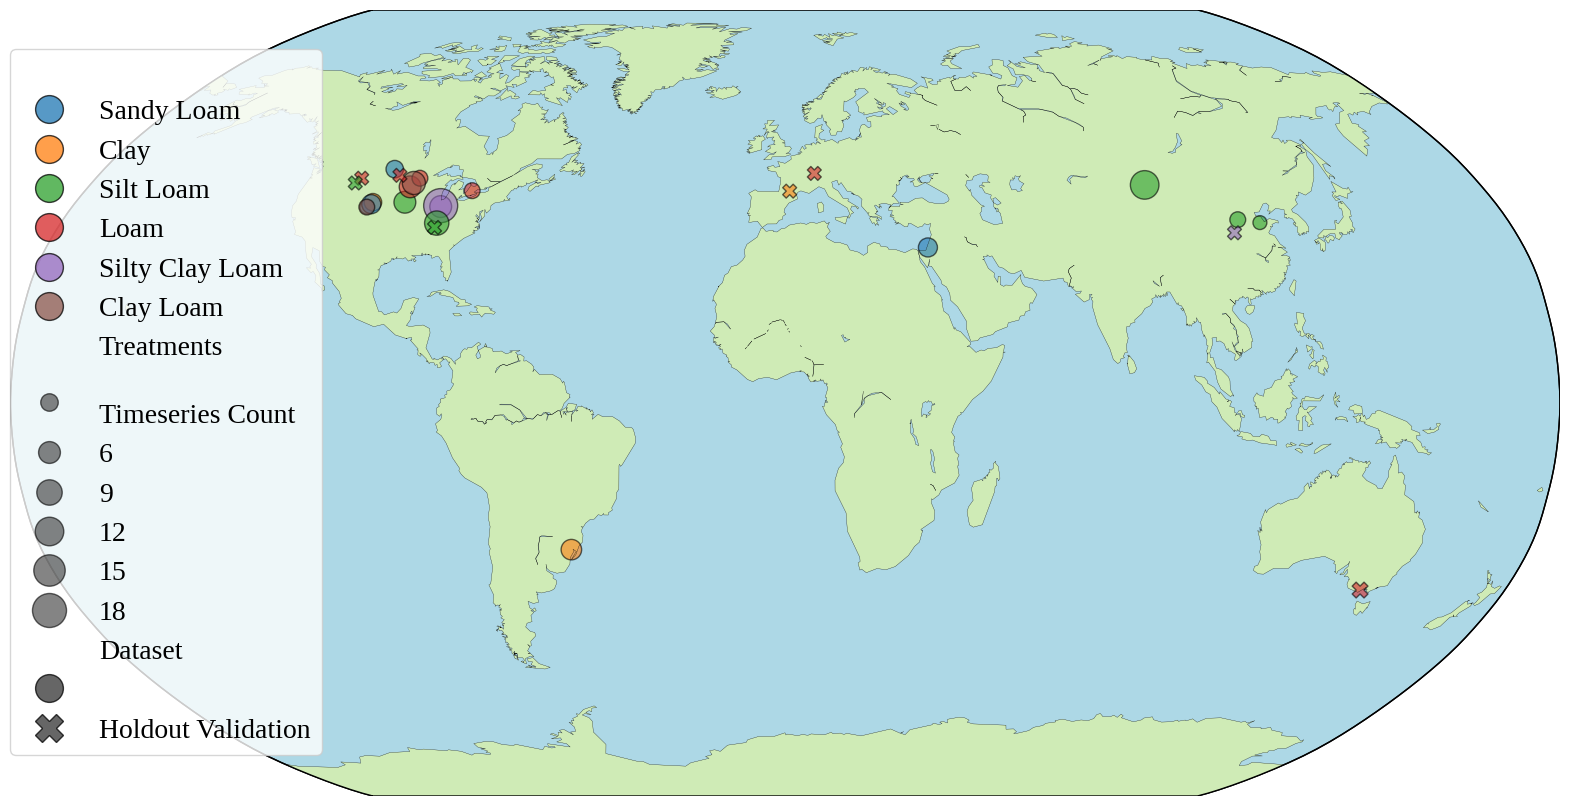

In [ ]:
# Figure 3: Bubble map showing the distribution of datasets and soil textures

mapdf = pd.read_csv("map.csv")
# Order mapdf by Dataset Z to A
mapdf = mapdf.sort_values(by='Dataset', ascending=False)
from mpl_toolkits.basemap import Basemap

# When multiple rows have the same latitude and longitude, manually add  a small amount of noise to the latitude and longitude
# Get the indexes of rows where the lat/long combination is not unique
non_unique_indices = mapdf[mapdf.duplicated(subset=['Latitude', 'Longitude'], keep=False)].index

# Add a small amount of noise to the latitude and longitude
i = 0
for index in non_unique_indices:
    # if i is odd, add a small amount of noise to the latitude and longitude.
    if i % 2 == 1:
        mapdf.at[index, 'Latitude'] += 0.5
        mapdf.at[index, 'Longitude'] += 0.5
    # if i is even, subtract a small amount of noise to the latitude and longitude.
    else:
        mapdf.at[index, 'Latitude'] -= 0.5
        mapdf.at[index, 'Longitude'] -= 0.5
    i += 1

# Create a bubble map using seaborn
plt.figure(figsize=(20, 16))
m = Basemap(projection='robin', lon_0=0, lat_0=0, resolution='c')
m.fillcontinents(color='#CFEBB6', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')
#m.drawcountries(linewidth=0.5, color='k')
m.drawcoastlines(linewidth=0.2, color='black')
# Plot bubbles
x, y = m(mapdf['Longitude'], mapdf['Latitude'])
# Vary shape of markers based on dataset
g = sns.scatterplot(x=x, y=y, size=mapdf['Treatments'], sizes=(100, 600),  alpha=0.6, hue=mapdf['Texture'], edgecolor='black' , linewidth=1, style=mapdf['Dataset'])

# Set legend font size
plt.rcParams['legend.fontsize'] = 20
# Set legend title font size
plt.rcParams['legend.title_fontsize'] = 20
plt.rc('font', family='Liberation Serif')
# Set legend position

# Set the color legend marker size
handles, labels = g.get_legend_handles_labels()
for handle in handles[:8]:
    handle.set_markersize(20)
    # Set alpha
    handle.set_alpha(0.75)
for handle in handles[15:]:
    handle.set_markersize(20)
    # Set alpha
    handle.set_alpha(0.75)
# Set label
labels[0] = ''
labels[15] = ''
# Set font style to bold on 8th label
labels[8] = '\nTimeseries Count'

plt.legend(handles, labels, bbox_to_anchor=(0.00, 0.95), loc=2, borderaxespad=0., )


# Save seaborn plot as svg
plt.savefig('bubble_map.png', dpi=600, bbox_inches='tight')
# Show the plot
plt.show()


<>:8: SyntaxWarning:

invalid escape sequence '\m'

<>:8: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_1742/1858931361.py:8: SyntaxWarning:

invalid escape sequence '\m'



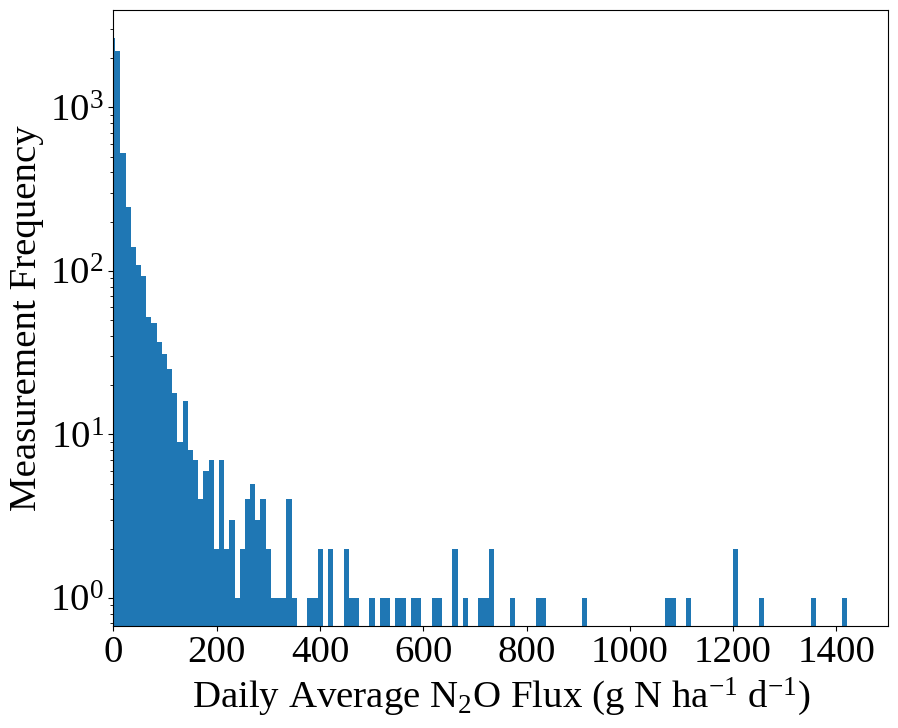

In [ ]:
# Figure 2: Histogram of N2O Flux values

# Set fig size
plt.figure(figsize=(10, 8))
# Get the range of the N2OFlux column
fluxrange = alldata['N2OFlux'].max() - alldata['N2OFlux'].min()
bins = int(fluxrange/10)
plt.hist(alldata['N2OFlux'], bins=bins)
plt.xlabel('Daily Average $\mathregular{N_{2}O}$ Flux (g N $\mathregular{ha^{-1}}$ $\mathregular{d^{-1}}$)')
plt.ylabel('Measurement Frequency')
# Use log scale for y axis
plt.yscale('log')
# set x min and max
plt.xlim(0, 1501)
# Set x ticks
plt.xticks(np.arange(0, 1401, 200))
# Set font size to 20
plt.rc('font', size=28)
# Save seaborn plot as svg
plt.savefig('N2OFlux_hist.tif', dpi=600, bbox_inches='tight')
plt.show()

Index(['$\mathit{Zea\ mays}$ (Corn)', '$\mathit{Glycine\ max}$ (Soybean)',
       'Grassland', '$\mathit{Triticum\ aestivum}$ (Wheat)',
       '$\mathit{Panicum\ virgatum}$ (Switchgrass)',
       '$\mathit{Hordeum\ vulgare}$ (Barley)',
       '$\mathit{Medicago\ sativa}$ (Alfalfa)',
       '$\mathit{Pisum\ sativum}$ (Pea)',
       '$\mathit{Miscanthus\ giganteus}$ (Miscanthus)',
       '$\mathit{Sorghum\ bicolor}$ (Sorghum)',
       '$\mathit{Gossypium\ hirsutum}$ (Cotton)'],
      dtype='object', name='PrimaryCrop')


/tmp/ipykernel_1742/3207364228.py:33: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1742/3207364228.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_1742/3207364228.py:50: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



<Figure size 2000x1600 with 0 Axes>

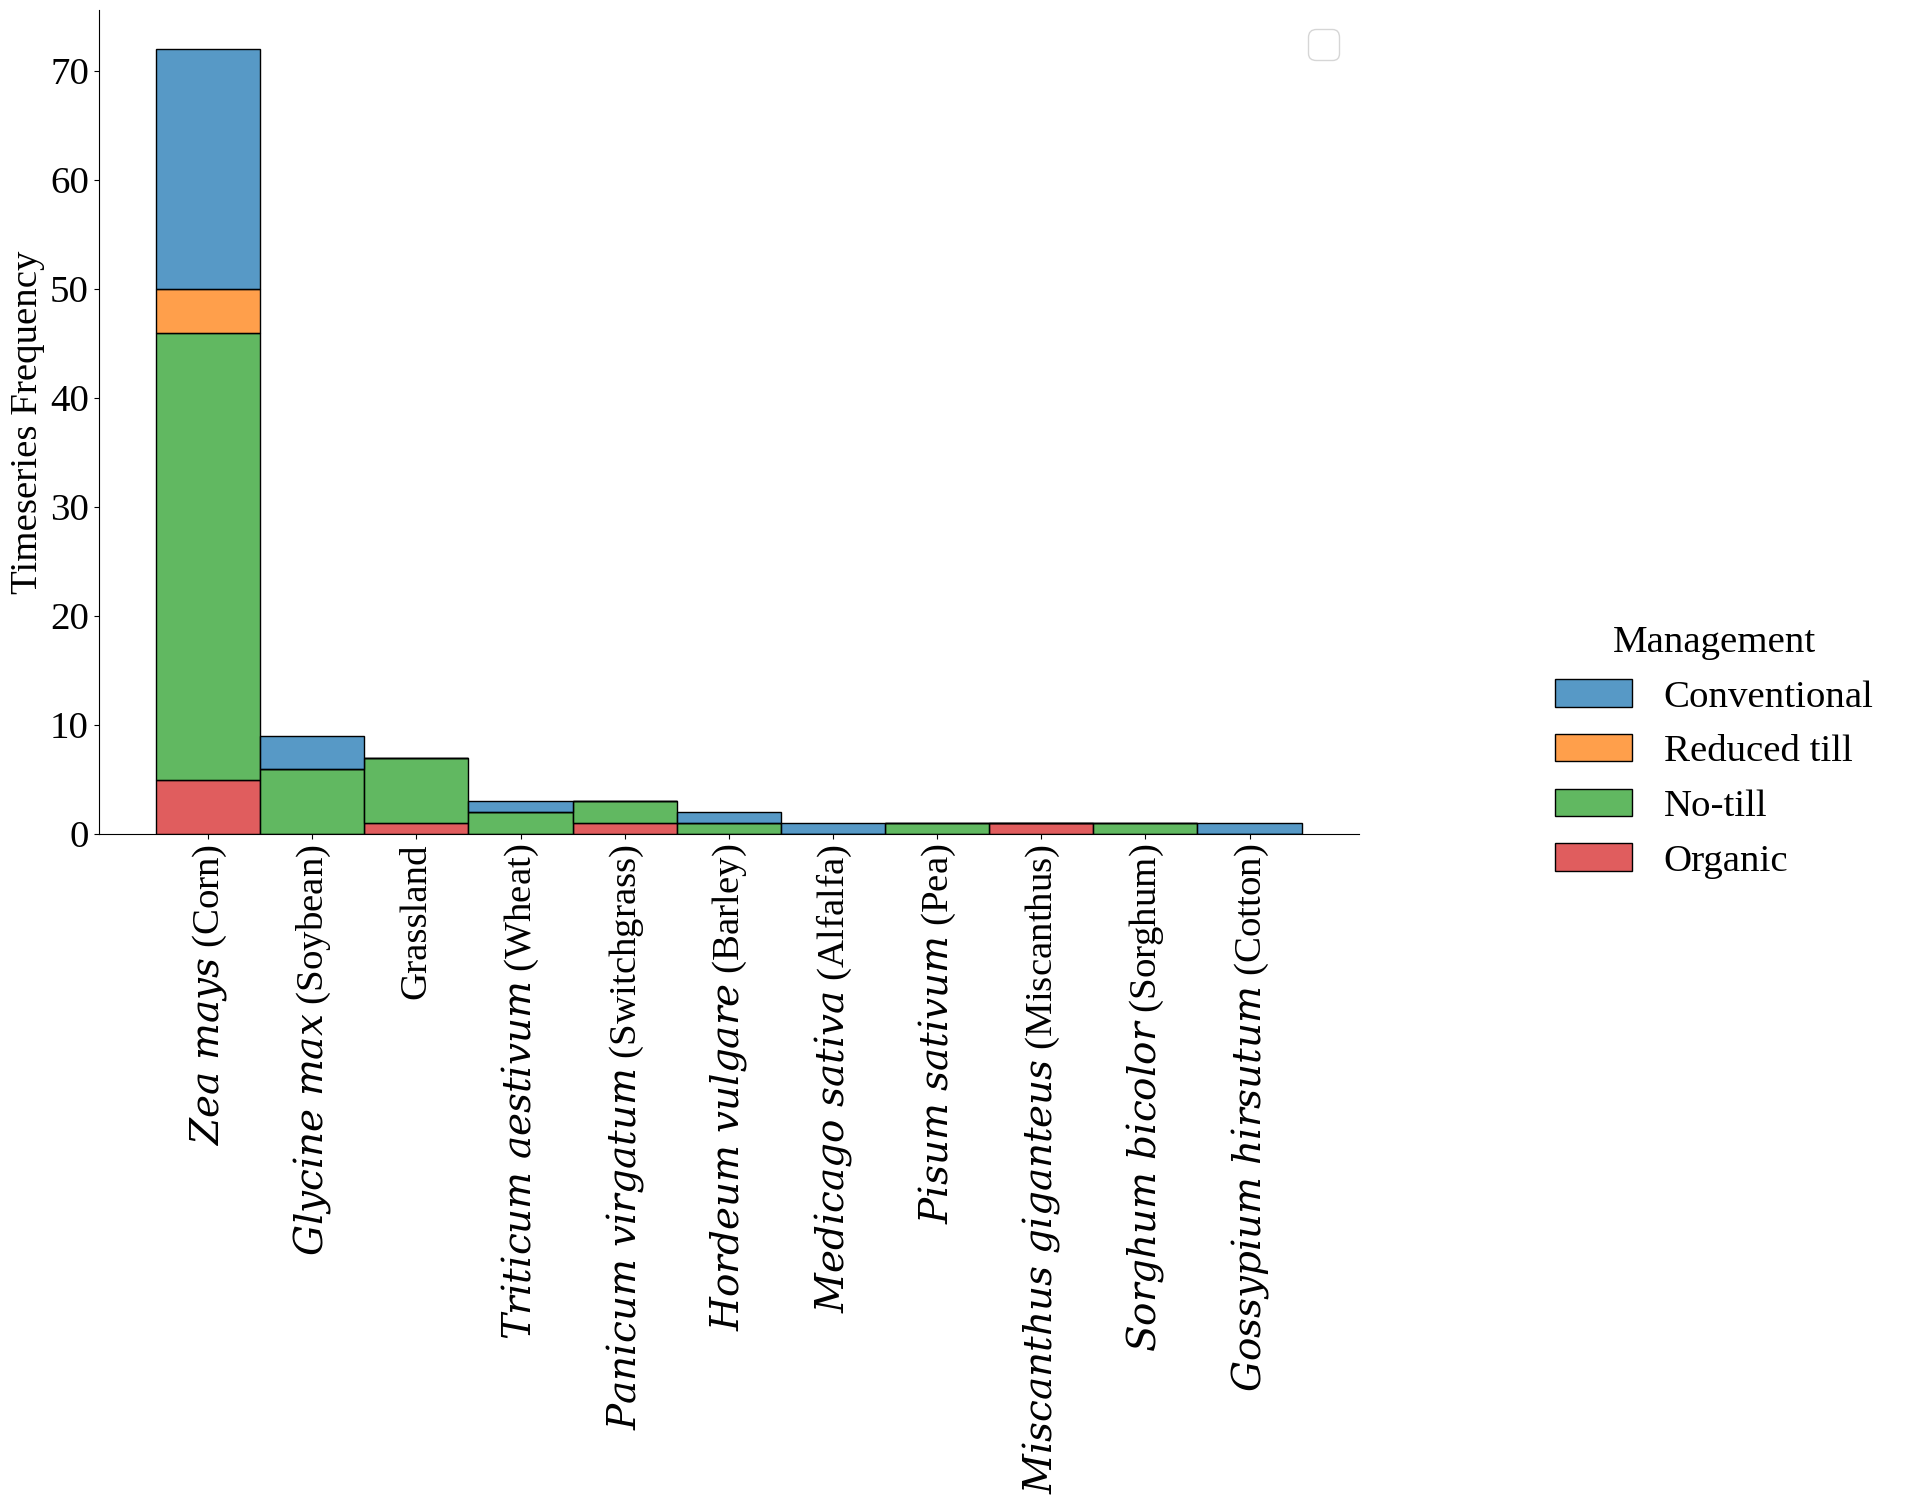

In [ ]:
# Figure 2: Histogram of crops and management practices

# Set fig size
plt.figure(figsize=(20, 16))
# Create a stacked bar graph of the number of treatment IDs with X as PrimaryCrop and hue as Management
bardata = alldata.drop_duplicates(subset='TreatmentID')
plt.rcParams['mathtext.fontset'] = 'dejavuserif'  # or 'stix', 'cm'

# Set scientific names to italic and common names in parentheses, non italicized
bardata.loc[bardata['PrimaryCrop'].str.contains('Corn'), 'PrimaryCrop'] = r'$\mathit{Zea\ mays}$ (Corn)'

bardata.loc[bardata['PrimaryCrop'].str.contains('Soy'), 'PrimaryCrop'] = r'$\mathit{Glycine\ max}$ (Soybean)'

bardata.loc[bardata['PrimaryCrop'].str.contains('Barley'), 'PrimaryCrop'] = r'$\mathit{Hordeum\ vulgare}$ (Barley)'

bardata.loc[bardata['PrimaryCrop'].str.contains('Alfalfa'), 'PrimaryCrop'] = r'$\mathit{Medicago\ sativa}$ (Alfalfa)'

bardata.loc[bardata['PrimaryCrop'].str.contains('Switchgrass'), 'PrimaryCrop'] = r'$\mathit{Panicum\ virgatum}$ (Switchgrass)'

bardata.loc[bardata['PrimaryCrop'].str.contains('Rye'), 'PrimaryCrop'] = r'$\mathit{Lolium\ perenne}$ (Ryegrass)'

bardata.loc[bardata['PrimaryCrop'].str.contains('Sorghum'), 'PrimaryCrop'] = r'$\mathit{Sorghum\ bicolor}$ (Sorghum)'

bardata.loc[bardata['PrimaryCrop'].str.contains('Wheat'), 'PrimaryCrop'] = r'$\mathit{Triticum\ aestivum}$ (Wheat)'

bardata.loc[bardata['PrimaryCrop'].str.contains('Pisum'), 'PrimaryCrop'] = r'$\mathit{Pisum\ sativum}$ (Pea)'

bardata.loc[bardata['PrimaryCrop'].str.contains('Miscanthus'), 'PrimaryCrop'] = r'$\mathit{Miscanthus\ giganteus}$ (Miscanthus)'

bardata.loc[bardata['PrimaryCrop'].str.contains('Cotton'), 'PrimaryCrop'] = r'$\mathit{Gossypium\ hirsutum}$ (Cotton)'
vc = bardata['PrimaryCrop'].value_counts().index
print((vc))

bardata['PrimaryCrop'] = pd.Categorical(bardata['PrimaryCrop'], categories=vc, ordered=True)

plt.rc('font', size=28)
# Set font to times new roman
plt.rc('font', family='Liberation Serif')
#plt.rc('text', usetex=True)
sns.displot(data=bardata, x='PrimaryCrop', hue='Management', multiple='stack', height=10, aspect=16/10)
plt.xticks(rotation=90)
# Set x axis label
plt.xlabel('')
# Set y axis label
plt.ylabel('Timeseries Frequency')

# Update the x axis labels
plt.gca().set_xticklabels(plt.gca().get_xticklabels())

# Set the legend font size
plt.legend(fontsize=28)

# Save seaborn plot as svg
plt.savefig('crop_mgmt_bar.svg', dpi=600, bbox_inches='tight')
plt.show()

[-0.2  0.   0.2  0.4  0.6  0.8]
[-20, 0, 20, 40, 60, 80]


/tmp/ipykernel_1742/714726450.py:30: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



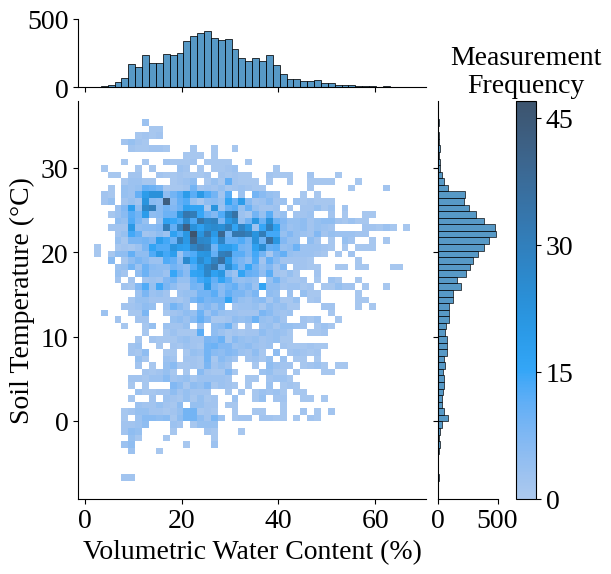

In [ ]:
# Figure 1: Jointplot of VWC and SoilT

plt.rc('font', size=20)

kdeplot = sns.jointplot(data=alldata, x='VWC', y='SoilT',  kind='hist', cbar=True, marginal_ticks=True, )
plt.subplots_adjust(left=0.1, right=0.8, top=0.9, bottom=0.1)
# get the current positions of the joint ax and the ax for the marginal x
pos_joint_ax = kdeplot.ax_joint.get_position()
pos_marg_x_ax = kdeplot.ax_marg_x.get_position()
# reposition the joint ax so it has the same width as the marginal x ax
kdeplot.ax_joint.set_position([pos_joint_ax.x0, pos_joint_ax.y0, pos_marg_x_ax.width, pos_joint_ax.height])
# reposition the colorbar using new x positions and y positions of the joint ax
kdeplot.fig.axes[-1].set_position([.83, pos_joint_ax.y0, .07, pos_joint_ax.height])
# Add colorbar title
kdeplot.fig.axes[-1].set_title('Measurement\nFrequency', fontsize=20)
# Set the histogram y limits
kdeplot.ax_marg_y.set_xlim(0,505)
kdeplot.ax_marg_x.set_ylim(0,500)
kdeplot.ax_marg_x.set_ylabel('')
kdeplot.ax_marg_y.set_xlabel('')
kdeplot.ax_joint.set_xlabel('Volumetric Water Content (%)')
kdeplot.ax_joint.set_ylabel('Soil Temperature (°C)')

# Set x axis tick labels to percentage (Multiply by 100)
xticks = kdeplot.ax_joint.get_xticks()
print(xticks)
xticks = [int(float(xtick)*100) for xtick in xticks]
print(xticks)
kdeplot.ax_joint.set_xticklabels(xticks)

# Set colorbar ticks
colorbar = kdeplot.fig.axes[-1]
colorbar.set_yticks([0, 15, 30, 45, ])
colorbar.set_yticklabels(['0', '15', '30', '45'])

# Save seaborn plot as svg
plt.savefig('VWC_SoilT_joint.png', dpi=600, bbox_inches='tight')
plt.show()

# Feature Scaling and Splitting to X, Y, and holdout datasets 

In [ ]:
# Set X and Y
X = alldata.drop(['N2OFlux', 'TreatmentID', 'HMMCD', 'Date', 'RawID', 'HMTruth', 'PubTitle', 'Citation',
'VWC_days_since_last_measurement', 'VWC_days_until_next_measurement', ], axis = 1)

# Scale continuous variables
X_cont = X.drop(['PrimaryCrop', 'Management', 'last_fert_type', 'ExperimentID', 'Group'], axis = 1)
scaler = MinMaxScaler()
cols = X_cont.columns
X_scale = scaler.fit_transform(X_cont.to_numpy())
X_cont = pd.DataFrame(X_scale, columns=cols)

# Scale nominal variables with one hot encoding
X_nom = X[['PrimaryCrop', 'Management', 'last_fert_type']]
X_nom = pd.concat([X_nom,pd.get_dummies(X_nom['last_fert_type'], prefix='NitrogenType')],axis=1)
X_nom = pd.concat([X_nom,pd.get_dummies(X_nom['PrimaryCrop'], prefix='PrimaryCrop')],axis=1)
X_nom = pd.concat([X_nom,pd.get_dummies(X_nom['Management'], prefix='Management')],axis=1)
X_nom = X_nom.drop(['PrimaryCrop', 'Management', 'last_fert_type'], axis = 1)

X_cont.reset_index(drop=True, inplace=True)
X_nom.reset_index(drop=True, inplace=True)
scaled_df = pd.concat([X_cont, X_nom], axis=1, join='inner')

scaled_df['HMTruth'] = list(alldata['HMTruth'])
scaled_df['N2OFlux'] = list(alldata['N2OFlux'])
scaled_df['HMMCD'] = list(alldata['HMMCD'])
scaled_df['RawID'] = list(alldata['RawID'])
scaled_df['TreatmentID'] = list(alldata['TreatmentID'])
scaled_df['ExperimentID'] = list(alldata['ExperimentID'])
scaled_df['Group'] = list(alldata['Group'])

X = scaled_df.drop(['HMMCD', 'HMTruth', 'HMIQR', 'HMMAD', 'N2OFlux', 'NitrogenApplied'], axis = 1)
Y = scaled_df[['HMTruth', 'TreatmentID', 'RawID', 'HMMCD', 'NitrogenApplied', 'N2OFlux', 'last_fert', 'NitrogenType_ESN', 'NitrogenType_Urea',
               'NitrogenType_UAN', 'HMIQR', 'HMMAD', 'ExperimentID', 'Group']]

# Add unscaled 'VWC', 'SoilT', 'Precip' to Y
Y['VWC'] = list(alldata['VWC'])
Y['SoilT'] = list(alldata['SoilT'])

# Add last_fert_type to X
X_plus = X
X_plus['last_fert_type'] = list(alldata['last_fert_type'])
# Add the unscaled days_since_fert to X plus
X_plus['days_since_fert'] = list(alldata['days_since_fert'])


KeyError: "['VWC_days_since_last_measurement', 'VWC_days_until_next_measurement'] not found in axis"

In [ ]:
# Get all the experimentids that only have one year of data, i.e. there is only one unique year associated with the experimentid
single_year_experiments = []
alldata['Year'] = pd.to_datetime(alldata['Date']).dt.year
for id in alldata['ExperimentID'].unique():
    if len(alldata[alldata['ExperimentID'] == id]['Year'].unique()) == 1:
        single_year_experiments.append(id)
print(single_year_experiments)

# Print experiments with more than one year of data
multi_year_experiments = []
for id in alldata['ExperimentID'].unique():
    if len(alldata[alldata['ExperimentID'] == id]['Year'].unique()) > 1:
        multi_year_experiments.append(id)
print(multi_year_experiments)

# Filter to only include multi-year experiments
X_multiyear_experiments = X[X['ExperimentID'].isin(multi_year_experiments)]
X_singleyear_experiments = X[X['ExperimentID'].isin(single_year_experiments)]
Y_multiyear_experiments = Y[Y['ExperimentID'].isin(multi_year_experiments)]
Y_singleyear_experiments = Y[Y['ExperimentID'].isin(single_year_experiments)]
X_plus_multiyear_experiments = X_plus[X_plus['ExperimentID'].isin(multi_year_experiments)]
X_plus_singleyear_experiments = X_plus[X_plus['ExperimentID'].isin(single_year_experiments)]

[2, 4, 22, 29, 49, 53, 54]
[6, 8, 9, 24, 27, 30, 32, 35, 37, 39, 42, 43, 44, 45, 50, 51, 55, 58]


In [ ]:
# Save to csv
X_multiyear_experiments.to_csv("X_all-YEAR_SEPARATED.csv", index=False)
Y_multiyear_experiments.to_csv("Y_all-YEAR_SEPARATED.csv", index=False)
X_plus_multiyear_experiments.to_csv("X_plus-YEAR_SEPARATED.csv", index=False)
X_singleyear_experiments.to_csv("X_singleyear-YEAR_SEPARATED.csv", index=False)
Y_singleyear_experiments.to_csv("Y_singleyear-YEAR_SEPARATED.csv", index=False)
X_plus_singleyear_experiments.to_csv("X_plus_singleyear-YEAR_SEPARATED.csv", index=False)

In [ ]:
# Load X and Y
X = pd.read_csv("X_all-YEAR_SEPARATED.csv")

Y = pd.read_csv("Y_all-YEAR_SEPARATED.csv")

In [ ]:
# Load holdout datasets
X_holdout = pd.read_csv("X_plus_singleyear-YEAR_SEPARATED.csv")

Y_holdout = pd.read_csv("Y_plus_singleyear-YEAR_SEPARATED.csv")

## XGBoost Model

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.metrics import make_scorer, matthews_corrcoef

random_grid = {
    'n_estimators': [100, 500, 1000, 2000],
    'max_depth': [10, 20, 30, 50, 110, 200, None],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1],
    'subsample': [0.5, .7, 1],
    'min_split_loss': [1, 2, 5, 10, 20],
    'max_delta_step': [0, 1, 2, 5, 10],
    'min_child_weight': [1, 2, 4, 6, 8],
    'reg_alpha': [0, 1, 2, 5, 10, 13, 15, 20],
    'reg_lambda': [0, 1, 2, 5, 10],
    'booster': ['gbtree', 'gblinear', 'dart'],
    'scale_pos_weight': [0.5, 1, 2, 5, 10],
    'nthread': [-1],
    'base_score': [0.1, 0.25, 0.4, 0.5, 0.75],
    'objective': ['binary:logistic'],
    'device': ['cpu'],
    'validate_parameters': ['true'],
    'rate_drop': [0, 0.05, 0.1, 0.3, 0.5],
    'skip_drop': [0.1, 0.5],
    }

# Load X and Y
X = pd.read_csv('X_all-YEAR_SEPARATED.csv')
Y = pd.read_csv('Y_all-YEAR_SEPARATED.csv')

# Drop last_fert_type column
X = X.drop(['last_fert_type'], axis=1)

# Use the random grid to search for best hyperparameters
# First create the base model to tune
xgb = XGBClassifier()
# Random search of parameters, using 5 fold cross validation,
# search across 100 different combinations, and use all available cores and stratify the folds
groups = X['Group']
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1)
# Create MCC scorer
mcc_scorer = make_scorer(matthews_corrcoef)
xgb_random = RandomizedSearchCV(estimator = xgb, scoring=mcc_scorer, param_distributions = random_grid, n_iter = 100, verbose=2, random_state=42, n_jobs = -1, cv=cv) # Fit the random search model
xgb_random.fit(X.drop(['TreatmentID', 'ExperimentID', 'RawID', 'Group'], axis = 1), Y['HMTruth'], groups=groups)

In [ ]:
# Print the best parameters and the best score
print(xgb_random.best_params_)
print(xgb_random.best_score_)

In [ ]:
print(xgb_random.best_params_)
print(xgb_random.best_score_)

In [ ]:
# Implement a 5-fold cross validation manually using the best hyperparameters 
mcd_accuracy_list = []
mcd_mcc_list = []
mad_accuracy_list = []
mad_mcc_list = []
iqr_accuracy_list = []
iqr_mcc_list = []
true_accuracy_list = []
true_mcc_list = []
true_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])
mcd_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])
mad_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])
iqr_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])

xgb_classifier = XGBClassifier(booster='gbtree', subsample=0.7, scale_pos_weight=2,
     tree_method='hist', nthread=1, device='cuda', predictor='gpu_predictor',
     n_estimators=2000, objective='binary:logistic', base_score=0.25,
     max_delta_step=0,
     min_split_loss=1, min_child_weight=2, max_depth=20, learning_rate=0.01,
     reg_lambda=0, reg_alpha=13,
     validate_parameters=True,)

# Segment the dataset into 5 equal and stratified parts
groups = X['Group']
folds = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1).split(X, Y['HMTruth'], groups=groups)

In [ ]:
# Drop last_fert_type column
try:
  X = X.drop(['last_fert_type'], axis=1)
except:
  pass

fold_results_df = pd.DataFrame(columns=['MCD Accuracy', 'MCD MCC', 'MAD Accuracy', 
                    'MAD MCC', 'IQR Accuracy', 'IQR MCC', 'True Accuracy', 
                    'True MCC'])

mcd_accuracy_list = []
mcd_mcc_list = []
mad_accuracy_list = []
mad_mcc_list = []
iqr_accuracy_list = []
iqr_mcc_list = []
true_accuracy_list = []
true_mcc_list = []

# Iterate through the folds. Train the model based on data labels based on hand labeling,
# MCD, MAD, and IQR separately. Make predictions and store the accuracy and MCC for each fold.

for train_index, test_index in folds:
    # Get all the RawID values in the testing set
    test_raw_ids = X['RawID'].iloc[test_index]
    # Get the HMTruth values of Y where 'RawID' column value is in test_raw_ids
    test_truth = Y['HMTruth'].loc[Y['RawID'].isin(test_raw_ids)]
    # Get the TreatmentID values of X where 'RawID' column value is in test_raw_ids
    test_treatment_ids = X['TreatmentID'].loc[X['RawID'].isin(test_raw_ids)]
    test_fluxes = Y['N2OFlux'].loc[Y['RawID'].isin(test_raw_ids)]

    ######### MCD #########
    # Train the model on the training set
    model = xgb_classifier.fit(X.drop(['TreatmentID', 'ExperimentID', 'RawID', 'Group'], axis = 1).iloc[train_index], Y['HMMCD'].iloc[train_index])
    # Make predictions on the testing set
    model.set_params(rate_drop=0)
    predictions = model.predict(X.drop(['TreatmentID', 'ExperimentID', 'RawID', 'Group'], axis = 1).iloc[test_index])
    # Calculate the probabilities of the predictions
    probabilities = model.predict_proba(X.drop(['TreatmentID', 'ExperimentID', 'RawID', 'Group'], axis = 1).iloc[test_index])

    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    mcd_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    mcd_mcc_list.append(mcc)
    fold_results_df['MCD Accuracy'] = pd.Series(mcd_accuracy_list)
    fold_results_df['MCD MCC'] = pd.Series(mcd_mcc_list)
    fold_results_df.to_csv('xgb_mcd_fold_performance.csv', index=False)

    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    predictions_df = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'N2OFlux': test_fluxes, 'Prediction': predictions, 'Probability_0': [prob[0] for prob in probabilities], 'Probability': [prob[1] for prob in probabilities]})
    # Append the DataFrame to the true_predictions DataFrame
    mcd_predictions = pd.concat([mcd_predictions, predictions_df], ignore_index=True)
    mcd_predictions.to_csv('xgb_mcd_predictions-YEAR-Separated.csv', index=False)

    ########## MAD #########
    # Train the model on the training set
    model = xgb_classifier.fit(X.drop(['TreatmentID', 'ExperimentID', 'RawID', 'Group'], axis = 1).iloc[train_index], Y['HMMAD'].iloc[train_index])
    # Make predictions on the testing set
    model.set_params(rate_drop=0)
    predictions = model.predict(X.drop(['TreatmentID', 'ExperimentID', 'RawID', 'Group'], axis = 1).iloc[test_index])
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    mad_accuracy_list.append(accuracy)    
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    mad_mcc_list.append(mcc)
    fold_results_df['MAD Accuracy'] = pd.Series(mad_accuracy_list)
    fold_results_df['MAD MCC'] = pd.Series(mad_mcc_list)
    fold_results_df.to_csv('xgb_mad_fold_performance.csv', index=False)

    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    predictions_df = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'N2OFlux': test_fluxes, 'Prediction': predictions})
    # Append the DataFrame to the true_predictions DataFrame
    mad_predictions = pd.concat([mad_predictions, predictions_df], ignore_index=True)
    mad_predictions.to_csv('xgb_mad_predictions-YEAR-Separated.csv', index=False)

    ########## IQR #########
    # Train the model on the training set
    model = xgb_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMIQR'].iloc[train_index])
    # Make predictions on the testing set
    model.set_params(rate_drop=0)
    predictions = model.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    iqr_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    iqr_mcc_list.append(mcc)
    fold_results_df['IQR Accuracy'] = pd.Series(iqr_accuracy_list)
    fold_results_df['IQR MCC'] = pd.Series(iqr_mcc_list)
    fold_results_df.to_csv('xgb_iqr_fold_performance.csv', index=False)

    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    predictions_df = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'N2OFlux': test_fluxes, 'Prediction': predictions})
    # Append the DataFrame to the true_predictions DataFrame
    iqr_predictions = pd.concat([iqr_predictions, predictions_df], ignore_index=True)
    iqr_predictions.to_csv('xgb_iqr_predictions-YEAR-Separated.csv', index=False)

    ########## True ##########
    # Train the model on the training set
    model = xgb_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMTruth'].iloc[train_index])
    # Make predictions on the testing set
    model.set_params(rate_drop=0)
    predictions = model.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])

    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    true_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    true_mcc_list.append(mcc)
    fold_results_df['True Accuracy'] = pd.Series(true_accuracy_list)
    fold_results_df['True MCC'] = pd.Series(true_mcc_list)
    fold_results_df.to_csv('xgb_true_fold_performance.csv', index=False)

    calibrated_clf = CalibratedClassifierCV(xgb_classifier, method='sigmoid', cv=5)
    calibrated_clf.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMTruth'].iloc[train_index])
    prediction_scores = calibrated_clf.predict_proba(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    prediction_scores = [score[1] for score in prediction_scores]

    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    predictions_df = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'N2OFlux': test_fluxes, 'Prediction': predictions})
    # Save predictions df
    # Append the DataFrame to the true_predictions DataFrame
    true_predictions = pd.concat([true_predictions, predictions_df], ignore_index=True)

    # Save predictions each fold
    true_predictions.to_csv('xgb_true_predictions-YEAR-Separated.csv', index=False)


/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning:

[16:48:54] WARNING: /workspace/src/context.cc:49: No visible GPU is found, setting device to CPU.

/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning:

[16:48:54] WARNING: /workspace/src/context.cc:203: XGBoost is not compiled with CUDA support.

/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning:

[16:48:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor" } are not used.


/opt/conda/lib/python3.12/site-packages/xgboost/core.py:2676: UserWarning:

[16:49:05] WARNING: /workspace/src/context.cc:49: No visible GPU is found, setting device to CPU.

/opt/conda/lib/python3.12/site-packages/xgboost/core.py:2676: UserWarning:

[16:49:05] WARNING: /workspace/src/context.cc:203: XGBoost is not compiled with CUDA support.

/opt/conda/lib/python3.12/site-packages/xgboost/core.py:2676: UserWarning:

[16:49:05] WARNING: /workspace/src/learner.cc:738: 

In [ ]:
 # Print the results
print("MCD Accuracy:", np.mean(mcd_accuracy_list))
print("MCD MCC:", np.mean(mcd_mcc_list))
print("MAD Accuracy:", np.mean(mad_accuracy_list))
print("MAD MCC:", np.mean(mad_mcc_list))
print("IQR Accuracy:", np.mean(iqr_accuracy_list))
print("IQR MCC:", np.mean(iqr_mcc_list))
print("True Accuracy:", np.mean(true_accuracy_list))
print("True MCC:", np.mean(true_mcc_list))

# Save the fold results to a CSV
df = pd.DataFrame({'MCD Accuracy': mcd_accuracy_list[:], 'MCD MCC': mcd_mcc_list[:], 'MAD Accuracy': mad_accuracy_list[:], 'MAD MCC': mad_mcc_list[:],
                   'IQR Accuracy': iqr_accuracy_list[:], 'IQR MCC': iqr_mcc_list[:], 'True Accuracy': true_accuracy_list[:], 'True MCC': true_mcc_list[:]})
df.to_csv('xgb_fold_results.csv', index=False)
# Save predictions to a CSV
true_predictions.to_csv('xgb_true_predictions-YEAR-Separated.csv', index=False)
mcd_predictions.to_csv('xgb_mcd_predictions-YEAR-Separated.csv', index=False)
mad_predictions.to_csv('xgb_mad_predictions-YEAR-Separated.csv', index=False)
iqr_predictions.to_csv('xgb_iqr_predictions-YEAR-Separated.csv', index=False)

MCD Accuracy: 0.8199915361967918
MCD MCC: 0.5098810547920599
MAD Accuracy: 0.8232935349658692
MAD MCC: 0.50596203843549
IQR Accuracy: 0.8161848684129049
IQR MCC: 0.40986723460021396
True Accuracy: 0.8345542248501034
True MCC: 0.5197809864078102


In [ ]:
# Train XGB model on the complete X dataset
import pickle

try:
    X = X.drop(['last_fert_type'], axis=1)
except:
    pass

xgb_classifier = XGBClassifier(booster='gbtree', subsample=0.7, scale_pos_weight=2,
     tree_method='hist', nthread=1, device='cpu',
     n_estimators=2000, objective='binary:logistic', base_score=0.25,
     max_delta_step=0,
     min_split_loss=1, min_child_weight=2, max_depth=20, learning_rate=0.01,
     reg_lambda=0, reg_alpha=13,
     validate_parameters=True,)

# Fit MCD model
xgb_classifier.fit(X.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group']), Y['HMMCD'])
# Pickle the model
with open('xgb_mcd_classifier_full.pkl', 'wb') as f:
    pickle.dump(xgb_classifier, f)

# Fit MAD model
xgb_classifier.fit(X.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group']), Y['HMMAD'])
# Pickle the model
with open('xgb_mad_classifier_full.pkl', 'wb') as f:
    pickle.dump(xgb_classifier, f)

# Fit IQR model
xgb_classifier.fit(X.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group']), Y['HMIQR'])
# Pickle the model
with open('xgb_iqr_classifier_full.pkl', 'wb') as f:
    pickle.dump(xgb_classifier, f)

# Fit True model
xgb_classifier.fit(X.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group']), Y['HMTruth'])
# Pickle the model
with open('xgb_true_classifier_full.pkl', 'wb') as f:
    pickle.dump(xgb_classifier, f)


In [ ]:
# Calculate Holdout MCC

# Predict on holdout
X_holdout = pd.read_csv('X_singleyear-YEAR_SEPARATED.csv')
Y_holdout = pd.read_csv('Y_singleyear-YEAR_SEPARATED.csv')

# Load MCD model
with open('xgb_mcd_classifier_full.pkl', 'rb') as f:
    xgb_classifier = pickle.load(f)
holdout_pred = xgb_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
mcd_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)

# Load MAD model
with open('xgb_mad_classifier_full.pkl', 'rb') as f:
    xgb_classifier = pickle.load(f)
holdout_pred = xgb_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
mad_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)

# Load IQR model
with open('xgb_iqr_classifier_full.pkl', 'rb') as f:
    xgb_classifier = pickle.load(f)
holdout_pred = xgb_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
iqr_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)

# Load True model
with open('xgb_true_classifier_full.pkl', 'rb') as f:
    xgb_classifier = pickle.load(f)
holdout_pred = xgb_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
true_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)

print("MCD Holdout MCC: ", mcd_mcc)
print("MAD Holdout MCC: ", mad_mcc)
print("IQR Holdout MCC: ", iqr_mcc)
print("True Holdout MCC: ", true_mcc)

MCD Holdout MCC:  0.47919525563120846
MAD Holdout MCC:  0.32271094035422443
IQR Holdout MCC:  0.2480968878780899
True Holdout MCC:  0.3328518822436524


In [ ]:
# Load the pickle file
with open('xgb_classifier_full.pkl', 'rb') as f:
    xgb_classifier = pickle.load(f)

In [ ]:
# Predict on training/testing
# Load XGB true unseen year predictions
xgb_predictions = pd.read_csv('xgb_mcd_predictions-YEAR-Separated.csv')

# For each unique treatmentID, calculate the time and flux percentage of HMTruth and predicted
performancedf = pd.DataFrame(columns=['TreatmentID', 'HMTruthTimePercentage', 'HMTruthFluxPercentage', 'PredictedTimePercentage', 'PredictedFluxPercentage'])
for treatmentID in xgb_predictions['TreatmentID'].unique():
    treatmentdf = xgb_predictions.loc[xgb_predictions['TreatmentID'] == treatmentID]
    # If HMTruth is always 1
    if int(1) in treatmentdf['HMTruth'].values:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    # If HMTruth is always 0,
    elif treatmentdf['HMTruth'].value_counts()[0] == len(treatmentdf['HMTruth']):
        truehmtime = 0
        truehmflux = 0
    else:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()

    # If predicted is always 0
    if int(1) in treatmentdf['Prediction'].values:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
        predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    elif treatmentdf['Prediction'].value_counts()[0] == len(treatmentdf['Prediction']):
        predictedhmtime = 0
        predictedhmflux = 0
    else:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
        predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    new_row = pd.DataFrame([{
            'TreatmentID': treatmentID,
            'HMTruthTimePercentage': truehmtime,
            'HMTruthFluxPercentage': truehmflux,
            'PredictedTimePercentage': predictedhmtime,
            'PredictedFluxPercentage': predictedhmflux
        }])
    performancedf = pd.concat([performancedf, new_row], ignore_index=True)
# Save performancedf to csv
performancedf.to_csv('xgb_testing_performance.csv', index=False)

# Print the mean and standard error of each column
print('HMTruthTimePercentage: ', np.mean(performancedf['HMTruthTimePercentage']), '+/-', stats.sem(performancedf['HMTruthTimePercentage']))
print('HMTruthFluxPercentage: ', np.mean(performancedf['HMTruthFluxPercentage']), '+/-', stats.sem(performancedf['HMTruthFluxPercentage']))
print('PredictedTimePercentage: ', np.mean(performancedf['PredictedTimePercentage']), '+/-', stats.sem(performancedf['PredictedTimePercentage']))
print('PredictedFluxPercentage: ', np.mean(performancedf['PredictedFluxPercentage']), '+/-', stats.sem(performancedf['PredictedFluxPercentage']))

/tmp/ipykernel_1742/1153021565.py:38: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



HMTruthTimePercentage:  0.23365978341365412 +/- 0.013893951470242442
HMTruthFluxPercentage:  0.7230991161975558 +/- 0.057995164698163265
PredictedTimePercentage:  0.24179210257851272 +/- 0.014072255279027258
PredictedFluxPercentage:  0.6004314265918282 +/- 0.06248087525305296


In [ ]:
import pickle
# Predict on holdout
# Load the best model
with open('xgb_mcd_classifier_full.pkl', 'rb') as f:
    xgb_classifier = pickle.load(f)
X_holdout = pd.read_csv('X_singleyear-YEAR_SEPARATED.csv')
Y_holdout = pd.read_csv('Y_singleyear-YEAR_SEPARATED.csv')
holdout_pred = xgb_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
# Add predictions to Y_holdout
Y_holdout['Prediction'] = holdout_pred

# For each unique treatmentID, calculate the time and flux percentage of HMTruth and predicted
performancedf = pd.DataFrame(columns=['TreatmentID', 'HMTruthTimePercentage', 'HMTruthFluxPercentage', 'PredictedTimePercentage', 'PredictedFluxPercentage'])
for treatmentID in Y_holdout['TreatmentID'].unique():
    treatmentdf = Y_holdout.loc[Y_holdout['TreatmentID'] == treatmentID]
    # If HMTruth is always 0,
    if treatmentdf['HMTruth'].value_counts()[0] == len(treatmentdf['HMTruth']):
        truehmtime = 0
        truehmflux = 0
    else:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()

    # If predicted is always 0
    if treatmentdf['Prediction'].value_counts()[0] == len(treatmentdf['Prediction']):
        predictedhmtime = 0
        predictedhmflux = 0
    else:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
    predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    new_row = pd.DataFrame([{
            'TreatmentID': treatmentID,
            'HMTruthTimePercentage': truehmtime,
            'HMTruthFluxPercentage': truehmflux,
            'PredictedTimePercentage': predictedhmtime,
            'PredictedFluxPercentage': predictedhmflux
        }])
    performancedf = pd.concat([performancedf, new_row], ignore_index=True)

# Calculate MCC of holdout prediction
xgb_holdout_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], Y_holdout['Prediction'])
print("MCC: ", xgb_holdout_mcc)

# Save performancedf to csv
performancedf.to_csv('xgb_holdout_performance.csv', index=False)
# Print the mean and standard error of each column
print('HMTruthTimePercentage: ', np.mean(performancedf['HMTruthTimePercentage']), '+/-', stats.sem(performancedf['HMTruthTimePercentage']))
print('HMTruthFluxPercentage: ', np.mean(performancedf['HMTruthFluxPercentage']), '+/-', stats.sem(performancedf['HMTruthFluxPercentage']))
print('PredictedTimePercentage: ', np.mean(performancedf['PredictedTimePercentage']), '+/-', stats.sem(performancedf['PredictedTimePercentage']))
print('PredictedFluxPercentage: ', np.mean(performancedf['PredictedFluxPercentage']), '+/-', stats.sem(performancedf['PredictedFluxPercentage']))

MCC:  0.47919525563120846
HMTruthTimePercentage:  0.18630335419653965 +/- 0.028050910686515124
HMTruthFluxPercentage:  0.5304319489882049 +/- 0.0650304472639839
PredictedTimePercentage:  0.2079205206824074 +/- 0.039836319036910185
PredictedFluxPercentage:  0.5257555214303999 +/- 0.10449138927051431


/tmp/ipykernel_1742/2372359151.py:38: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



# MLP Model

In [9]:
from sklearn.neural_network import MLPClassifier

random_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (200, 100), (100, 50), 
                           (150, 75), (250, 125), (100, 50, 25), 
                           (150, 100, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['lbfgs',], 
    'alpha': [0.0001, 0.001, 0.01], 
    #'learning_rate_init': [0.0001, 0.001, 0.01],  # For adam/sgd only
    'max_iter': [1000, 2000, 5000, 10000],
    'early_stopping': [True],
    'validation_fraction': [0.1], 
}

# Drop last_fert_type column
X = X.drop(['last_fert_type'], axis=1)

# Use the random grid to search for best hyperparameters
# First create the base model to tune
mlp = MLPClassifier()
# Random search of parameters, using 3 fold cross validation,
# search across 100 different combinations, 
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1)
groups = X['Group']

# Create MCC scorer
mcc_scorer = make_scorer(matthews_corrcoef)

mlp_random = RandomizedSearchCV(estimator = mlp, scoring=mcc_scorer, 
                                param_distributions = random_grid, 
                                n_iter = 100, verbose=2, random_state=42, 
                                n_jobs = -1, cv=cv, refit=False) 
# Fit the random search model
mlp_random.fit(X.drop(['TreatmentID', 'ExperimentID', 'RawID', 'Group'], 
                      axis = 1), Y['HMTruth'], groups=groups)
# View the best parameters
print("Best Parameters:", mlp_random.best_params_)
print("Best MCC: ", mlp_random.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS R


[CV] END activation=tanh, alpha=0.001, early_stopping=True, hidden_layer_sizes=(50,), learning_rate_init=0.01, max_iter=1000, solver=lbfgs, validation_fraction=0.1; total time=   0.0s
[CV] END activation=tanh, alpha=0.001, early_stopping=True, hidden_layer_sizes=(50,), learning_rate_init=0.01, max_iter=1000, solver=lbfgs, validation_fraction=0.1; total time=   0.0s
[CV] END activation=tanh, alpha=0.001, early_stopping=True, hidden_layer_sizes=(50,), learning_rate_init=0.01, max_iter=1000, solver=lbfgs, validation_fraction=0.1; total time=   0.0s
[CV] END activation=tanh, alpha=0.01, early_stopping=True, hidden_layer_sizes=(50, 50), learning_rate_init=0.001, max_iter=1000, solver=lbfgs, validation_fraction=0.1; total time=   0.0s
[CV] END activation=tanh, alpha=0.01, early_stopping=True, hidden_layer_sizes=(50, 50), learning_rate_init=0.001, max_iter=1000, solver=lbfgs, validation_fraction=0.1; total time=   0.0s
[CV] END activation=tanh, alpha=0.01, early_stopping=True, hidden_layer_s

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS R


[CV] END activation=relu, alpha=0.001, early_stopping=True, hidden_layer_sizes=(150, 75), learning_rate_init=0.01, max_iter=500, solver=adam, validation_fraction=0.1; total time=   0.0s
[CV] END activation=relu, alpha=0.001, early_stopping=True, hidden_layer_sizes=(150, 75), learning_rate_init=0.01, max_iter=500, solver=adam, validation_fraction=0.1; total time=   0.0s
[CV] END activation=relu, alpha=0.001, early_stopping=True, hidden_layer_sizes=(150, 75), learning_rate_init=0.01, max_iter=500, solver=adam, validation_fraction=0.1; total time=   0.0s
[CV] END activation=relu, alpha=0.001, early_stopping=True, hidden_layer_sizes=(150, 75), learning_rate_init=0.01, max_iter=500, solver=adam, validation_fraction=0.1; total time=   0.0s
[CV] END activation=relu, alpha=0.001, early_stopping=True, hidden_layer_sizes=(150, 75), learning_rate_init=0.01, max_iter=500, solver=adam, validation_fraction=0.1; total time=   0.0s
[CV] END activation=relu, alpha=0.0001, early_stopping=True, hidden_l

...

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS R


[CV] END activation=tanh, alpha=0.0001, early_stopping=True, hidden_layer_sizes=(50, 50), learning_rate_init=0.01, max_iter=1000, solver=adam, validation_fraction=0.1; total time=   2.4s
[CV] END activation=tanh, alpha=0.0001, early_stopping=True, hidden_layer_sizes=(50, 50), learning_rate_init=0.01, max_iter=1000, solver=adam, validation_fraction=0.1; total time=   1.3s
[CV] END activation=tanh, alpha=0.0001, early_stopping=True, hidden_layer_sizes=(50, 50), learning_rate_init=0.01, max_iter=1000, solver=adam, validation_fraction=0.1; total time=   1.8s
[CV] END activation=tanh, alpha=0.0001, early_stopping=True, hidden_layer_sizes=(50, 50), learning_rate_init=0.01, max_iter=1000, solver=adam, validation_fraction=0.1; total time=   0.9s
[CV] END activation=tanh, alpha=0.0001, early_stopping=True, hidden_layer_sizes=(50, 50), learning_rate_init=0.01, max_iter=1000, solver=adam, validation_fraction=0.1; total time=   1.4s
[CV] END activation=tanh, alpha=0.0001, early_stopping=True, hid

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS R

Best Parameters: {'validation_fraction': 0.1, 'solver': 'lbfgs', 'max_iter': 2000, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (150, 75), 'early_stopping': True, 'alpha': 0.001, 'activation': 'relu'}
Best MCC:  0.5209592929614522


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html



In [11]:
# Print the best parameters
print("Best Parameters:", mlp_random.best_params_)
print("Best MCC: ", mlp_random.best_score_)

Best Parameters: {'validation_fraction': 0.1, 'solver': 'lbfgs', 'max_iter': 2000, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (150, 75), 'early_stopping': True, 'alpha': 0.001, 'activation': 'relu'}
Best MCC:  0.5209592929614522


In [ ]:
from sklearn.neural_network import MLPClassifier

# Implement a 5-fold cross validation manually
mcd_accuracy_list = []
mcd_mcc_list = []
mad_accuracy_list = []
mad_mcc_list = []
iqr_accuracy_list = []
iqr_mcc_list = []
true_accuracy_list = []
true_mcc_list = []
true_mlp_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction',])
mcd_mlp_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction',])
mad_mlp_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction',])
iqr_mlp_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction',])

# Current best params
mlp_classifier = MLPClassifier(validation_fraction=0.1, solver='lbfgs', 
                               max_iter=5000, hidden_layer_sizes=(100, 50, 25),
                               early_stopping=True, alpha=0.001, 
                               activation='relu')

groups = X['Group']
folds = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1).split(X, Y['HMTruth'], groups=groups)

# Iterate through the folds
for train_index, test_index in folds:
    # Get all the RawID values in the testing set
    test_raw_ids = X['RawID'].iloc[test_index]
    # Get the HMTruth values of Y where 'RawID' column value is in test_raw_ids
    test_truth = Y.loc[Y['RawID'].isin(test_raw_ids), 'HMTruth']
    # Get the TreatmentID values of X where 'RawID' column value is in test_raw_ids
    test_treatment_ids = X.loc[X['RawID'].isin(test_raw_ids), 'TreatmentID']

    ######### MCD #########
    # Train the model on the training set
    mlp_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMMCD'].iloc[train_index])
    # Make predictions on the testing set
    predictions = mlp_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])

    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    mcd_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    mcd_mcc_list.append(mcc)
    # Create a DataFrame with the RawID, HMTruth, and predictions
    predictions_df = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions})
    # Append the DataFrame to the true_predictions DataFrame
    mcd_mlp_predictions = pd.concat([mcd_mlp_predictions, predictions_df], ignore_index=True)

    ######### MAD #########
    # Train the model on the training set
    mlp_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMMAD'].iloc[train_index])
    # Make predictions on the testing set
    predictions = mlp_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    mad_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    mad_mcc_list.append(mcc)
    # Create a DataFrame with the RawID, HMTruth, and predictions
    predictions_df = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions})
    # Append the DataFrame to the true_predictions DataFrame
    mad_mlp_predictions = pd.concat([mad_mlp_predictions, predictions_df], ignore_index=True)

    ######### IQR #########
    # Train the model on the training set
    mlp_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMIQR'].iloc[train_index])
    # Make predictions on the testing set
    predictions = mlp_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    iqr_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    iqr_mcc_list.append(mcc)
    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    predictions_df = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions})
    # Append the DataFrame to the true_predictions DataFrame
    iqr_mlp_predictions = pd.concat([iqr_mlp_predictions, predictions_df], ignore_index=True)

    ########## True ##########
    # Train the model on the training set
    mlp_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMTruth'].iloc[train_index])
    # Make predictions on the testing set
    predictions = mlp_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    true_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    true_mcc_list.append(mcc)
    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    predictions_df = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions})
    # Append the DataFrame to the true_predictions DataFrame
    true_mlp_predictions = pd.concat([true_mlp_predictions, predictions_df], ignore_index=True)

/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html

/tmp/ipykernel_1584/3719633352.py:62: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocess

In [125]:
# Print the accuracy and Matthews correlation coefficient for each fold
print(f"Accuracy for MCD: {np.mean(mcd_accuracy_list)}")
print(f"MCC for MCD: {np.mean(mcd_mcc_list)}")
print(f"Accuracy for MAD: {np.mean(mad_accuracy_list)}")
print(f"MCC for MAD: {np.mean(mad_mcc_list)}")
print(f"Accuracy for IQR: {np.mean(iqr_accuracy_list)}")
print(f"MCC for IQR: {np.mean(iqr_mcc_list)}")
print(f"Accuracy for True: {np.mean(true_accuracy_list)}")
print(f"MCC for True: {np.mean(true_mcc_list)}")

# Save the fold results to a CSV
fold_results = pd.DataFrame({
    'Fold': np.arange(1, 6),
    'MCD Accuracy': mcd_accuracy_list,
    'MCD MCC': mcd_mcc_list,
    'MAD Accuracy': mad_accuracy_list,
    'MAD MCC': mad_mcc_list,
    'IQR Accuracy': iqr_accuracy_list,
    'IQR MCC': iqr_mcc_list,
    'True Accuracy': true_accuracy_list,
    'True MCC': true_mcc_list
})

fold_results.to_csv('mlp_fold_results.csv', index=False)
# Save predictions to a CSV
true_mlp_predictions.to_csv('true_mlp_predictions.csv', index=False)
mcd_mlp_predictions.to_csv('mcd_mlp_predictions.csv', index=False)
mad_mlp_predictions.to_csv('mad_mlp_predictions.csv', index=False)
iqr_mlp_predictions.to_csv('iqr_mlp_predictions.csv', index=False)

Accuracy for MCD: 0.8199582533047695
MCC for MCD: 0.48470896748331577
Accuracy for MAD: 0.81760593689014
MCC for MAD: 0.479282051734482
Accuracy for IQR: 0.807176518103596
MCC for IQR: 0.3699978505364124
Accuracy for True: 0.8302673144208598
MCC for True: 0.49869992652475226


In [127]:
# Train MLP model on the complete X dataset
import pickle

try:
    X = X.drop(['last_fert_type'], axis=1)
except:
    pass

mlp_classifier = MLPClassifier(validation_fraction=0.1, solver='lbfgs', 
                               max_iter=5000, hidden_layer_sizes=(100, 50, 25),
                               early_stopping=True, alpha=0.001, 
                               activation='relu')

# Fit MCD Classifier
mlp_classifier.fit(X.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group']), Y['HMMCD'])
# Pickle the model
with open('mlp_mcd_classifier_full.pkl', 'wb') as f:
    pickle.dump(mlp_classifier, f)

# Fit MAD Classifier
mlp_classifier.fit(X.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group']), Y['HMMAD'])
# Pickle the model
with open('mlp_mad_classifier_full.pkl', 'wb') as f:
    pickle.dump(mlp_classifier, f)

# Fit IQR Classifier
mlp_classifier.fit(X.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group']), Y['HMIQR'])
# Pickle the model
with open('mlp_iqr_classifier_full.pkl', 'wb') as f:
    pickle.dump(mlp_classifier, f)

# Fit True Classifier
mlp_classifier.fit(X.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group']), Y['HMTruth'])
# Pickle the model
with open('mlp_true_classifier_full.pkl', 'wb') as f:
    pickle.dump(mlp_classifier, f)


/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html

/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html

/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/prepro

In [128]:
# Calculate Holdout MCC

# Predict on holdout
X_holdout = pd.read_csv('X_singleyear-YEAR_SEPARATED.csv')
Y_holdout = pd.read_csv('Y_singleyear-YEAR_SEPARATED.csv')

# Load MCD model
with open('mlp_mcd_classifier_full.pkl', 'rb') as f:
    mlp_classifier = pickle.load(f)
holdout_pred = mlp_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
mcd_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)
# Load MAD model
with open('mlp_mad_classifier_full.pkl', 'rb') as f:
    mlp_classifier = pickle.load(f)
holdout_pred = mlp_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
mad_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)
# Load IQR model
with open('mlp_iqr_classifier_full.pkl', 'rb') as f:
    mlp_classifier = pickle.load(f)
holdout_pred = mlp_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
iqr_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)
# Load True model
with open('mlp_true_classifier_full.pkl', 'rb') as f:
    mlp_classifier = pickle.load(f)
holdout_pred = mlp_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
true_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)

print("MCD Holdout MCC: ", mcd_mcc)
print("MAD Holdout MCC: ", mad_mcc)
print("IQR Holdout MCC: ", iqr_mcc)
print("True Holdout MCC: ", true_mcc)

MCD Holdout MCC:  0.41634029548835866
MAD Holdout MCC:  0.3777563380135816
IQR Holdout MCC:  0.4065571194795563
True Holdout MCC:  0.25579127419291686


In [ ]:
# Load the best model
with open('mlp_classifier_full.pkl', 'rb') as f:
    mlp_classifier = pickle.load(f)

In [ ]:
# Predict on training/testing
# Load mlp true unseen year predictions
mlp_predictions = pd.read_csv('mad_mlp_predictions.csv')

# For each unique treatmentID, calculate the time and flux percentage of HMTruth and predicted
performancedf = pd.DataFrame(columns=['TreatmentID', 'HMTruthTimePercentage', 'HMTruthFluxPercentage', 'PredictedTimePercentage', 'PredictedFluxPercentage'])
for treatmentID in mlp_predictions['TreatmentID'].unique():
    treatmentdf = mlp_predictions.loc[mlp_predictions['TreatmentID'] == treatmentID]
    # If HMTruth is always 1
    if int(1) in treatmentdf['HMTruth'].values:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    # If HMTruth is always 0,
    elif treatmentdf['HMTruth'].value_counts()[0] == len(treatmentdf['HMTruth']):
        truehmtime = 0
        truehmflux = 0
    else:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()

    # If predicted is always 0
    if int(1) in treatmentdf['Prediction'].values:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
        predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    elif treatmentdf['Prediction'].value_counts()[0] == len(treatmentdf['Prediction']):
        predictedhmtime = 0
        predictedhmflux = 0
    else:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
        predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    new_row = pd.DataFrame([{
            'TreatmentID': treatmentID,
            'HMTruthTimePercentage': truehmtime,
            'HMTruthFluxPercentage': truehmflux,
            'PredictedTimePercentage': predictedhmtime,
            'PredictedFluxPercentage': predictedhmflux
        }])
    performancedf = pd.concat([performancedf, new_row], ignore_index=True)
# Save performancedf to csv
performancedf.to_csv('mlp_testing_performance.csv', index=False)

KeyError: 'TreatmentID'

In [ ]:
# Predict on holdout
X_holdout = pd.read_csv('X_singleyear-YEAR_SEPARATED.csv')
Y_holdout = pd.read_csv('Y_singleyear-YEAR_SEPARATED.csv')
holdout_pred = mlp_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
# Add predictions to Y_holdout
Y_holdout['Prediction'] = holdout_pred

# For each unique treatmentID, calculate the time and flux percentage of HMTruth and predicted
performancedf = pd.DataFrame(columns=['TreatmentID', 'HMTruthTimePercentage', 'HMTruthFluxPercentage', 'PredictedTimePercentage', 'PredictedFluxPercentage'])
for treatmentID in Y_holdout['TreatmentID'].unique():
    treatmentdf = Y_holdout.loc[Y_holdout['TreatmentID'] == treatmentID]
    # If HMTruth is always 0,
    if treatmentdf['HMTruth'].value_counts()[0] == len(treatmentdf['HMTruth']):
        truehmtime = 0
        truehmflux = 0
    else:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()

    # If predicted is always 0
    if treatmentdf['Prediction'].value_counts()[0] == len(treatmentdf['Prediction']):
        predictedhmtime = 0
        predictedhmflux = 0
    else:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
    predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    new_row = pd.DataFrame([{
            'TreatmentID': treatmentID,
            'HMTruthTimePercentage': truehmtime,
            'HMTruthFluxPercentage': truehmflux,
            'PredictedTimePercentage': predictedhmtime,
            'PredictedFluxPercentage': predictedhmflux
        }])
    performancedf = pd.concat([performancedf, new_row], ignore_index=True)
# Calculate MCC of holdout prediction
mlp_holdout_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], Y_holdout['Prediction'])
print("MCC: ", mlp_holdout_mcc)
# Save performancedf to csv
performancedf.to_csv('mlp_holdout_performance.csv', index=False)
print('HMTruthTimePercentage: ', np.mean(performancedf['HMTruthTimePercentage']))
print('HMTruthFluxPercentage: ', np.mean(performancedf['HMTruthFluxPercentage']))
print('PredictedTimePercentage: ', np.mean(performancedf['PredictedTimePercentage']))
print('PredictedFluxPercentage: ', np.mean(performancedf['PredictedFluxPercentage']))

 ## Random Forest Model


In [21]:
random_grid = {
    'n_estimators': [100, 500, 1000, 2500, 5000],
    'max_depth': [5, 10, 20, 30, 50, None],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_leaf_nodes': [None, 10, 50, 100],
    'bootstrap': [True, False],
    'min_impurity_decrease': [0.0, 0.01, 0.05],
    'class_weight': ['balanced', 'balanced_subsample', None],
    }

# Create MCC scorer
mcc_scorer = make_scorer(matthews_corrcoef)

# Use the random grid to search for best hyperparameters
# First create the base model to tune
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
# Random search of parameters, using  cross validation,
# search across 100 different combinations, 
# and use all available cores and stratify the folds
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1)
groups = X['Group']

rf_random = RandomizedSearchCV(estimator = rf, scoring=mcc_scorer, 
                                param_distributions = random_grid, 
                                n_iter = 100, verbose=2, random_state=42, 
                                n_jobs = -1, cv=cv, refit=False) 
# Fit the random search model
rf_random.fit(X.drop(['TreatmentID', 'ExperimentID', 'RawID', 'Group'], 
                      axis = 1), Y['HMTruth'], groups=groups)


Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END bootstrap=False, class_weight=None, criterion=entropy, max_depth=30, max_features=sqrt, max_leaf_nodes=50, min_impurity_decrease=0.01, min_samples_leaf=8, min_samples_split=2, n_estimators=100; total time=   1.3s
[CV] END bootstrap=True, class_weight=balanced_subsample, criterion=gini, max_depth=30, max_features=sqrt, max_leaf_nodes=10, min_impurity_decrease=0.01, min_samples_leaf=4, min_samples_split=5, n_estimators=1000; total time=  11.1s
[CV] END bootstrap=True, class_weight=balanced_subsample, criterion=gini, max_depth=30, max_features=sqrt, max_leaf_nodes=10, min_impurity_decrease=0.01, min_samples_leaf=4, min_samples_split=5, n_estimators=1000; total time=  15.3s
[CV] END bootstrap=False, class_weight=balanced, criterion=gini, max_depth=50, max_features=None, max_leaf_nodes=100, min_impurity_decrease=0.01, min_samples_leaf=2, min_samples_split=10, n_estimators=1000; total time= 1.1min
[CV] END bootstrap=Fals

RandomizedSearchCV(cv=StratifiedGroupKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'class_weight': ['balanced',
                                                         'balanced_subsample',
                                                         None],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [5, 10, 20, 30, 50, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'max_leaf_nodes': [None, 10, 50, 100],
                                        'min_impurity_decrease': [0.0, 0.01,
                                                                  0.05],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [100, 500, 1000, 2500,
                                                         5000]},
                   random_state=0, refit=False, scoring='accuracy', verbose=2)

In [26]:
# Print the best parameters
print(rf_random.best_params_)
print(rf_random.best_score_)

{'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 2, 'min_impurity_decrease': 0.0, 'max_leaf_nodes': 100, 'max_features': 'sqrt', 'max_depth': 30, 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': True}
0.8308439660471196


In [164]:
# Implement a 5-fold cross validation manually
mcd_accuracy_list = []
mcd_mcc_list = []
mad_accuracy_list = []
mad_mcc_list = []
iqr_accuracy_list = []
iqr_mcc_list = []
true_accuracy_list = []
true_mcc_list = []
true_rf_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])
mcd_rf_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])
mad_rf_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])
iqr_rf_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])

rf_classifier = RandomForestClassifier(n_estimators= 500, 
                                        min_samples_split= 20, max_depth= 30,
                                        criterion='gini', min_samples_leaf=2,
                                        min_impurity_decrease=0,
                                        max_leaf_nodes=100, class_weight='balanced',
                                        max_features='sqrt', bootstrap=False,
                                      )

# Segment the dataset into 5 equal and stratified parts
groups = X['Group']
folds = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1).split(X, Y['HMTruth'], groups=groups)

# Iterate through the folds
for train_index, test_index in folds:
    # Get all the RawID values in the testing set
    test_raw_ids = X['RawID'].iloc[test_index]
    # Get the HMTruth values of Y where 'RawID' column value is in test_raw_ids
    test_truth = Y['HMTruth'].loc[Y['RawID'].isin(test_raw_ids)]
    # Get the TreatmentID values of X where 'RawID' column value is in test_raw_ids
    test_treatment_ids = X['TreatmentID'].loc[X['RawID'].isin(test_raw_ids)]
    # Get the N2OFlux values of Y where 'RawID' column value is in test_raw_ids
    test_n2oflux = Y['N2OFlux'].loc[Y['RawID'].isin(test_raw_ids)]

    ######### MCD #########
    # Train the model on the training set
    rf_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMMCD'].iloc[train_index])
    # Make predictions on the testing set
    predictions = rf_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    mcd_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    mcd_mcc_list.append(mcc)
    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    predictions_df = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions, 'N2OFlux': test_n2oflux})
    # Append the DataFrame to the true_predictions DataFrame
    mcd_rf_predictions = pd.concat([mcd_rf_predictions, predictions_df], ignore_index=True)

    ########## MAD #########
    # Train the model on the training set
    rf_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMMAD'].iloc[train_index])
    # Make predictions on the testing set
    predictions = rf_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
   
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    mad_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    mad_mcc_list.append(mcc)
    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    predictions_df = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions, 'N2OFlux': test_n2oflux})
    # Append the DataFrame to the true_predictions DataFrame
    mad_rf_predictions = pd.concat([mad_rf_predictions, predictions_df], ignore_index=True)

    ########## IQR #########
    # Train the model on the training set
    rf_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMIQR'].iloc[train_index])
    # Make predictions on the testing set
    predictions = rf_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    iqr_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    iqr_mcc_list.append(mcc)
    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    predictions_df = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions, 'N2OFlux': test_n2oflux})
    # Append the DataFrame to the true_predictions DataFrame
    iqr_rf_predictions = pd.concat([iqr_rf_predictions, predictions_df], ignore_index=True)

    ########## True ##########
    # Train the model on the training set
    rf_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMTruth'].iloc[train_index])
    # Make predictions on the testing set
    predictions = rf_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    true_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    true_mcc_list.append(mcc)
    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    predictions_df = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions, 'N2OFlux': test_n2oflux})
    # Append the DataFrame to the true_predictions DataFrame
    true_rf_predictions = pd.concat([true_rf_predictions, predictions_df], ignore_index=True)


/tmp/ipykernel_1584/2066983453.py:53: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_1584/2066983453.py:70: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_1584/2066983453.py:87: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

In [165]:
# Print the accuracy and Matthews correlation coefficient for each fold
print(f"Accuracy for MCD: {np.mean(mcd_accuracy_list)}")
print(f"MCC for MCD: {np.mean(mcd_mcc_list)}")
print(f"Accuracy for MAD: {np.mean(mad_accuracy_list)}")
print(f"MCC for MAD: {np.mean(mad_mcc_list)}")
print(f"Accuracy for IQR: {np.mean(iqr_accuracy_list)}")
print(f"MCC for IQR: {np.mean(iqr_mcc_list)}")
print(f"Accuracy for True: {np.mean(true_accuracy_list)}")
print(f"MCC for True: {np.mean(true_mcc_list)}")

# Save the fold results to a CSV
fold_results = pd.DataFrame({
    'Fold': np.arange(1, 6),
    'MCD Accuracy': mcd_accuracy_list,
    'MCD MCC': mcd_mcc_list,
    'MAD Accuracy': mad_accuracy_list,
    'MAD MCC': mad_mcc_list,
    'IQR Accuracy': iqr_accuracy_list,
    'IQR MCC': iqr_mcc_list,
    'True Accuracy': true_accuracy_list,
    'True MCC': true_mcc_list
})
fold_results.to_csv('rf_fold_results.csv', index=False)
# Save predictions to a CSV
true_rf_predictions.to_csv('true_rf_predictions.csv', index=False)
mcd_rf_predictions.to_csv('mcd_rf_predictions.csv', index=False)
mad_rf_predictions.to_csv('mad_rf_predictions.csv', index=False)
iqr_rf_predictions.to_csv('iqr_rf_predictions.csv', index=False)

Accuracy for MCD: 0.8106390045075955
MCC for MCD: 0.4823986464555391
Accuracy for MAD: 0.8105831569925337
MCC for MAD: 0.4578885868505408
Accuracy for IQR: 0.816135752802265
MCC for IQR: 0.42147488632941477
Accuracy for True: 0.8195817888080625
MCC for True: 0.4791134712102546


In [139]:
# Train the model on the entire dataset
rf_classifier = RandomForestClassifier(n_estimators= 500, 
                                        min_samples_split= 20, max_depth= 30,
                                        criterion='gini', min_samples_leaf=2,
                                        min_impurity_decrease=0,
                                        max_leaf_nodes=100, class_weight='balanced',
                                        max_features='sqrt', bootstrap=False,
                                      )

# Fit the MCD Classifier
rf_classifier.fit(X.drop(['RawID', 'ExperimentID', 'TreatmentID', 'Group',], axis = 1), Y['HMMCD'])
# Pickle the model
with open('rf_mcd_classifier_full.pkl', 'wb') as f:
    pickle.dump(rf_classifier, f)

# Fit the MAD Classifier
rf_classifier.fit(X.drop(['RawID', 'ExperimentID', 'TreatmentID', 'Group', ], axis = 1), Y['HMMAD'])
# Pickle the model
with open('rf_mad_classifier_full.pkl', 'wb') as f:
    pickle.dump(rf_classifier, f)

# Fit the IQR Classifier
rf_classifier.fit(X.drop(['RawID', 'ExperimentID', 'TreatmentID', 'Group', ], axis = 1), Y['HMIQR'])
# Pickle the model
with open('rf_iqr_classifier_full.pkl', 'wb') as f:
    pickle.dump(rf_classifier, f)

# Fit the True Classifier
rf_classifier.fit(X.drop(['RawID', 'ExperimentID', 'TreatmentID', 'Group', ], axis = 1), Y['HMTruth'])
# Pickle the model
with open('rf_true_classifier_full.pkl', 'wb') as f:
    pickle.dump(rf_classifier, f)

In [140]:
# Calculate Holdout MCC
# Predict on holdout
X_holdout = pd.read_csv('X_singleyear-YEAR_SEPARATED.csv')
Y_holdout = pd.read_csv('Y_singleyear-YEAR_SEPARATED.csv')

# Load MCD model
with open('rf_mcd_classifier_full.pkl', 'rb') as f:
    rf_classifier = pickle.load(f)
holdout_pred = rf_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
mcd_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)
# Load MAD model
with open('rf_mad_classifier_full.pkl', 'rb') as f:
    rf_classifier = pickle.load(f)
holdout_pred = rf_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
mad_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)
# Load IQR model
with open('rf_iqr_classifier_full.pkl', 'rb') as f:
    rf_classifier = pickle.load(f)
holdout_pred = rf_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
iqr_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)
# Load True model
with open('rf_true_classifier_full.pkl', 'rb') as f:
    rf_classifier = pickle.load(f)
holdout_pred = rf_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
true_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)

print("MCD Holdout MCC: ", mcd_mcc)
print("MAD Holdout MCC: ", mad_mcc)
print("IQR Holdout MCC: ", iqr_mcc)
print("True Holdout MCC: ", true_mcc)

MCD Holdout MCC:  0.24089362896274064
MAD Holdout MCC:  0.16306116401204274
IQR Holdout MCC:  0.12237440392781829
True Holdout MCC:  0.16315701766229668


In [ ]:
# Load the best model
with open('RF_classification_model.sav', 'rb') as f:
    rf_classifier = pickle.load(f)

In [168]:
# Predict on training/testing
# Load rf true unseen year predictions
rf_predictions = pd.read_csv('mcd_rf_predictions.csv')

# For each unique treatmentID, calculate the time and flux percentage of HMTruth and predicted
performancedf = pd.DataFrame(columns=['TreatmentID', 'HMTruthTimePercentage', 'HMTruthFluxPercentage', 'PredictedTimePercentage', 'PredictedFluxPercentage'])
for treatmentID in rf_predictions['TreatmentID'].unique():
    treatmentdf = rf_predictions.loc[rf_predictions['TreatmentID'] == treatmentID]
    # If HMTruth is always 1
    if int(1) in treatmentdf['HMTruth'].values:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    # If HMTruth is always 0,
    elif treatmentdf['HMTruth'].value_counts()[0] == len(treatmentdf['HMTruth']):
        truehmtime = 0
        truehmflux = 0
    else:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()

    # If predicted is always 0
    if int(1) in treatmentdf['Prediction'].values:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
        predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    elif treatmentdf['Prediction'].value_counts()[0] == len(treatmentdf['Prediction']):
        predictedhmtime = 0
        predictedhmflux = 0
    else:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
        predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    new_row = pd.DataFrame([{
            'TreatmentID': treatmentID,
            'HMTruthTimePercentage': truehmtime,
            'HMTruthFluxPercentage': truehmflux,
            'PredictedTimePercentage': predictedhmtime,
            'PredictedFluxPercentage': predictedhmflux
        }])
    performancedf = pd.concat([performancedf, new_row], ignore_index=True)
# Save performancedf to csv
performancedf.to_csv('rf_testing_performance.csv', index=False)
print('HMTruthTimePercentage: ', np.mean(performancedf['HMTruthTimePercentage']))
print('HMTruthFluxPercentage: ', np.mean(performancedf['HMTruthFluxPercentage']))
print('PredictedTimePercentage: ', np.mean(performancedf['PredictedTimePercentage']))
print('PredictedFluxPercentage: ', np.mean(performancedf['PredictedFluxPercentage']))

/tmp/ipykernel_1584/1102372001.py:38: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



HMTruthTimePercentage:  0.23365978341365412
HMTruthFluxPercentage:  0.7230991161975558
PredictedTimePercentage:  0.26594990061044904
PredictedFluxPercentage:  0.592278814128844


In [169]:
# Predict on holdout
X_holdout = pd.read_csv('X_singleyear-YEAR_SEPARATED.csv')
Y_holdout = pd.read_csv('Y_singleyear-YEAR_SEPARATED.csv')
holdout_pred = mlp_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
# Add predictions to Y_holdout
Y_holdout['Prediction'] = holdout_pred

# For each unique treatmentID, calculate the time and flux percentage of HMTruth and predicted
performancedf = pd.DataFrame(columns=['TreatmentID', 'HMTruthTimePercentage', 'HMTruthFluxPercentage', 'PredictedTimePercentage', 'PredictedFluxPercentage'])
for treatmentID in Y_holdout['TreatmentID'].unique():
    treatmentdf = Y_holdout.loc[Y_holdout['TreatmentID'] == treatmentID]
    # If HMTruth is always 0,
    if treatmentdf['HMTruth'].value_counts()[0] == len(treatmentdf['HMTruth']):
        truehmtime = 0
        truehmflux = 0
    else:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()

    # If predicted is always 0
    if treatmentdf['Prediction'].value_counts()[0] == len(treatmentdf['Prediction']):
        predictedhmtime = 0
        predictedhmflux = 0
    else:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
    predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    new_row = pd.DataFrame([{
            'TreatmentID': treatmentID,
            'HMTruthTimePercentage': truehmtime,
            'HMTruthFluxPercentage': truehmflux,
            'PredictedTimePercentage': predictedhmtime,
            'PredictedFluxPercentage': predictedhmflux
        }])
    performancedf = pd.concat([performancedf, new_row], ignore_index=True)
# Calculate MCC of holdout prediction
rf_holdout_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], Y_holdout['Prediction'])
print("MCC: ", rf_holdout_mcc)
# Save performancedf to csv
performancedf.to_csv('rf_holdout_performance.csv', index=False)
print('HMTruthTimePercentage: ', np.mean(performancedf['HMTruthTimePercentage']))
print('HMTruthFluxPercentage: ', np.mean(performancedf['HMTruthFluxPercentage']))
print('PredictedTimePercentage: ', np.mean(performancedf['PredictedTimePercentage']))
print('PredictedFluxPercentage: ', np.mean(performancedf['PredictedFluxPercentage']))

MCC:  0.25579127419291686
HMTruthTimePercentage:  0.18630335419653965
HMTruthFluxPercentage:  0.5304319489882049
PredictedTimePercentage:  0.09830105614139827
PredictedFluxPercentage:  0.26130486726250024


/tmp/ipykernel_1584/1525982999.py:34: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



## KNN Model

In [41]:
from sklearn.neighbors import KNeighborsClassifier
random_grid = {
    'n_neighbors': [3, 11, 15, 31, 51, 75, 100],
    'weights': ['uniform', 'distance'],
    'p': [1, 2, 3],
    'leaf_size': [10, 30, 40, 50, 75, 100],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev']
}

# Create MCC scorer
mcc_scorer = make_scorer(matthews_corrcoef)

# Use the random grid to search for best hyperparameters
# First create the base model to tune
knn = KNeighborsClassifier(n_jobs=-1)
# Random search of parameters, using  cross validation,
# search across 100 different combinations, 
# and use all available cores and stratify the folds
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1)
groups = X['Group']

knn_search = RandomizedSearchCV(estimator = knn, scoring=mcc_scorer, 
                                param_distributions = random_grid, 
                                n_iter = 100, verbose=2, random_state=42, 
                                n_jobs = -1, cv=cv, refit=False) 
# Fit the random search model
knn_search.fit(X.drop(['TreatmentID', 'ExperimentID', 'RawID', 'Group'], 
                      axis = 1), Y['HMTruth'], groups=groups)

Fitting 5 folds for each of 100 candidates, totalling 500 fits

[CV] END leaf_size=10, metric=euclidean, n_neighbors=51, p=2, weights=distance; total time=   0.2s
[CV] END leaf_size=40, metric=minkowski, n_neighbors=11, p=2, weights=uniform; total time=   0.3s
[CV] END leaf_size=50, metric=euclidean, n_neighbors=100, p=1, weights=uniform; total time=   0.3s
[CV] END leaf_size=10, metric=minkowski, n_neighbors=3, p=1, weights=uniform; total time=   0.5s
[CV] END leaf_size=10, metric=minkowski, n_neighbors=3, p=1, weights=uniform; total time=   0.8s
[CV] END leaf_size=30, metric=minkowski, n_neighbors=51, p=1, weights=distance; total time=   1.0s
[CV] END leaf_size=50, metric=chebyshev, n_neighbors=31, p=1, weights=distance; total time=   1.0s
[CV] END leaf_size=40, metric=minkowski, n_neighbors=31, p=2, weights=uniform; total time=   0.2s
[CV] END leaf_size=40, metric=euclidean, n_neighbors=11, p=2, weights=distance; total time=   0.1s
[CV] END leaf_size=40, metric=manhattan, n_neighbor

RandomizedSearchCV(cv=StratifiedGroupKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=KNeighborsClassifier(n_jobs=-1), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'leaf_size': [10, 30, 40, 50, 75, 100],
                                        'metric': ['euclidean', 'manhattan',
                                                   'minkowski', 'chebyshev'],
                                        'n_neighbors': [3, 11, 15, 31, 51, 75,
                                                        100],
                                        'p': [1, 2, 3],
                                        'weights': ['uniform', 'distance']},
                   random_state=42, refit=False,
                   scoring=make_scorer(matthews_corrcoef), verbose=2)

In [122]:
# Print the best parameters and best score
print("Best Parameters:", knn_search.best_params_)
print("Best Score:", knn_search.best_score_)

NameError: name 'knn_search' is not defined

In [158]:
# Use optimized parameters
knn_classifier = KNeighborsClassifier(weights='distance', p=2, n_neighbors=31,
                                      metric='manhattan',
                                      leaf_size=10, algorithm='auto')

# Implement a 5-fold cross validation manually
mcd_accuracy_list = []
mcd_mcc_list = []
mad_accuracy_list = []
mad_mcc_list = []
iqr_accuracy_list = []
iqr_mcc_list = []
true_accuracy_list = []
true_mcc_list = []
true_knn_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])
mcd_knn_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])
mad_knn_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])
iqr_knn_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])

# Segment the dataset into 5 equal and stratified parts
groups = X['Group']
folds = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1).split(X, Y['HMTruth'], groups=groups)

# Iterate through the 10 folds
for train_index, test_index in folds:
    # Get all the RawID values in the testing set
    test_raw_ids = X['RawID'].iloc[test_index]
    # Get the HMTruth values of Y where 'RawID' column value is in test_raw_ids
    test_truth = Y['HMTruth'].loc[Y['RawID'].isin(test_raw_ids)]
    # Get the TreatmentID values of X where 'RawID' column value is in test_raw_ids
    test_treatment_ids = X['TreatmentID'].loc[X['RawID'].isin(test_raw_ids)]
    # Get the N2OFlux values of Y where 'RawID' column value is in test_raw_ids
    test_n2oflux = Y['N2OFlux'].loc[Y['RawID'].isin(test_raw_ids)]

    ######### MCD #########
    # Train the model on the training set
    knn_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMMCD'].iloc[train_index])
    # Make predictions on the testing set
    predictions = knn_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    mcd_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    mcd_mcc_list.append(mcc)
    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    knn_predictions = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions, 'N2OFlux': test_n2oflux})
    # Append the DataFrame to the true_knn_predictions DataFrame
    mcd_knn_predictions = pd.concat([mcd_knn_predictions, knn_predictions], ignore_index=True)

    ########## MAD #########
    # Train the model on the training set
    knn_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMMAD'].iloc[train_index])
    # Make predictions on the testing set
    predictions = knn_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    mad_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    mad_mcc_list.append(mcc)
    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    knn_predictions = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions, 'N2OFlux': test_n2oflux})
    # Append the DataFrame to the true_knn_predictions DataFrame
    mad_knn_predictions = pd.concat([mad_knn_predictions, knn_predictions], ignore_index=True)

    ########## IQR ##########
    # Train the model on the training set
    knn_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMIQR'].iloc[train_index])
    # Make predictions on the testing set
    predictions = knn_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    iqr_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    iqr_mcc_list.append(mcc)
    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    knn_predictions = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions, 'N2OFlux': test_n2oflux})
    # Append the DataFrame to the true_knn_predictions DataFrame
    iqr_knn_predictions = pd.concat([iqr_knn_predictions, knn_predictions], ignore_index=True)

    ########## True ##########
    # Train the model on the training set
    knn_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMTruth'].iloc[train_index])
    # Make predictions on the testing set
    predictions = knn_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    true_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    true_mcc_list.append(mcc)
    # Create a DataFrame with the RawID, TreatmentID, HMTruth, and predictions
    knn_predictions = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions, 'N2OFlux': test_n2oflux})
    # Append the DataFrame to the true_knn_predictions DataFrame
    true_knn_predictions = pd.concat([true_knn_predictions, knn_predictions], ignore_index=True)

/tmp/ipykernel_1584/2176570956.py:49: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_1584/2176570956.py:65: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_1584/2176570956.py:81: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

In [161]:
# Print the accuracy and Matthews correlation coefficient for each fold
print("MCD Accuracy:", np.mean(mcd_accuracy_list))
print("MCD MCC:", np.mean(mcd_mcc_list))
print("MAD Accuracy:", np.mean(mad_accuracy_list))
print("MAD MCC:", np.mean(mad_mcc_list))
print("IQR Accuracy:", np.mean(iqr_accuracy_list))
print("IQR MCC:", np.mean(iqr_mcc_list))
print("True Accuracy:", np.mean(true_accuracy_list))
print("True MCC:", np.mean(true_mcc_list))
# Save the fold results to a CSV
df = pd.DataFrame({'MCD Accuracy': mcd_accuracy_list, 'MCD MCC': mcd_mcc_list, 'MAD Accuracy': mad_accuracy_list, 'MAD MCC': mad_mcc_list,
                   'IQR Accuracy': iqr_accuracy_list, 'IQR MCC': iqr_mcc_list, 'True Accuracy': true_accuracy_list, 'True MCC': true_mcc_list})
df.to_csv('knn_fold_results.csv', index=False)
# Save predictions to a CSV
true_knn_predictions.to_csv('true_knn_predictions.csv', index=False)
mcd_knn_predictions.to_csv('mcd_knn_predictions.csv', index=False)
mad_knn_predictions.to_csv('mad_knn_predictions.csv', index=False)
iqr_knn_predictions.to_csv('iqr_knn_predictions.csv', index=False)

MCD Accuracy: 0.7888328831331203
MCD MCC: 0.37054469006952556
MAD Accuracy: 0.7937986061674647
MAD MCC: 0.37810761719815844
IQR Accuracy: 0.7942861200093432
IQR MCC: 0.31505456192076065
True Accuracy: 0.8028677992084626
True MCC: 0.3920570324752415


In [145]:
# Train the model on the entire dataset
knn_classifier = KNeighborsClassifier(weights='distance', p=2, n_neighbors=31,
                                      metric='manhattan',
                                      leaf_size=10, algorithm='auto')
# Fit the MCD Classifier
knn_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1), Y['HMMCD'])
# Pickle the model
with open('knn_mcd_classifier_full.pkl', 'wb') as f:
    pickle.dump(knn_classifier, f)

# Fit the MAD Classifier
knn_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1), Y['HMMAD'])
# Pickle the model
with open('knn_mad_classifier_full.pkl', 'wb') as f:
    pickle.dump(knn_classifier, f)

# Fit the IQR Classifier
knn_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1), Y['HMIQR'])
# Pickle the model
with open('knn_iqr_classifier_full.pkl', 'wb') as f:
    pickle.dump(knn_classifier, f)

# Fit the True Classifier
knn_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1), Y['HMTruth'])
# Pickle the model
with open('knn_true_classifier_full.pkl', 'wb') as f:
    pickle.dump(knn_classifier, f)

In [146]:
# Calculate the MCC of the holdout set

# Predict on holdout
X_holdout = pd.read_csv('X_singleyear-YEAR_SEPARATED.csv')
Y_holdout = pd.read_csv('Y_singleyear-YEAR_SEPARATED.csv')

# Load MCD model
with open('knn_mcd_classifier_full.pkl', 'rb') as f:
    knn_classifier = pickle.load(f)
holdout_pred = knn_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
mcd_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)
# Load MAD model
with open('knn_mad_classifier_full.pkl', 'rb') as f:
    knn_classifier = pickle.load(f)
holdout_pred = knn_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
mad_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)
# Load IQR model
with open('knn_iqr_classifier_full.pkl', 'rb') as f:
    knn_classifier = pickle.load(f)
holdout_pred = knn_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
iqr_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)
# Load True model
with open('knn_true_classifier_full.pkl', 'rb') as f:
    knn_classifier = pickle.load(f)
holdout_pred = knn_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
true_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)

print("MCD Holdout MCC: ", mcd_mcc)
print("MAD Holdout MCC: ", mad_mcc)
print("IQR Holdout MCC: ", iqr_mcc)
print("True Holdout MCC: ", true_mcc)

MCD Holdout MCC:  0.1570480340816351
MAD Holdout MCC:  0.19972403695679763
IQR Holdout MCC:  0.03677264848466337
True Holdout MCC:  0.07275077616492516


In [ ]:
# Load the best model
with open('knn_mcd_classifier_full.pkl', 'rb') as f:
    knn_classifier = pickle.load(f)

In [162]:
# Predict on training/testing
# Load knn true unseen year predictions
knn_predictions = pd.read_csv('mad_knn_predictions.csv')

# For each unique treatmentID, calculate the time and flux percentage of HMTruth and predicted
performancedf = pd.DataFrame(columns=['TreatmentID', 'HMTruthTimePercentage', 'HMTruthFluxPercentage', 'PredictedTimePercentage', 'PredictedFluxPercentage'])
for treatmentID in knn_predictions['TreatmentID'].unique():
    treatmentdf = knn_predictions.loc[knn_predictions['TreatmentID'] == treatmentID]
    # If HMTruth is always 1
    if int(1) in treatmentdf['HMTruth'].values:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    # If HMTruth is always 0,
    elif treatmentdf['HMTruth'].value_counts()[0] == len(treatmentdf['HMTruth']):
        truehmtime = 0
        truehmflux = 0
    else:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()

    # If predicted is always 0
    if int(1) in treatmentdf['Prediction'].values:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
        predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    elif treatmentdf['Prediction'].value_counts()[0] == len(treatmentdf['Prediction']):
        predictedhmtime = 0
        predictedhmflux = 0
    else:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
        predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    new_row = pd.DataFrame([{
            'TreatmentID': treatmentID,
            'HMTruthTimePercentage': truehmtime,
            'HMTruthFluxPercentage': truehmflux,
            'PredictedTimePercentage': predictedhmtime,
            'PredictedFluxPercentage': predictedhmflux
        }])
    performancedf = pd.concat([performancedf, new_row], ignore_index=True)
# Save performancedf to csv
performancedf.to_csv('knn_testing_performance.csv', index=False)
print('HMTruthTimePercentage: ', np.mean(performancedf['HMTruthTimePercentage']))
print('HMTruthFluxPercentage: ', np.mean(performancedf['HMTruthFluxPercentage']))
print('PredictedTimePercentage: ', np.mean(performancedf['PredictedTimePercentage']))
print('PredictedFluxPercentage: ', np.mean(performancedf['PredictedFluxPercentage']))

/tmp/ipykernel_1584/267950611.py:38: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



HMTruthTimePercentage:  0.23365978341365412
HMTruthFluxPercentage:  0.7230991161975558
PredictedTimePercentage:  0.1820269326263557
PredictedFluxPercentage:  0.4617795106040479


In [163]:
# Predict on holdout
X_holdout = pd.read_csv('X_singleyear-YEAR_SEPARATED.csv')
Y_holdout = pd.read_csv('Y_singleyear-YEAR_SEPARATED.csv')
holdout_pred = knn_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
# Add predictions to Y_holdout
Y_holdout['Prediction'] = holdout_pred

# For each unique treatmentID, calculate the time and flux percentage of HMTruth and predicted
performancedf = pd.DataFrame(columns=['TreatmentID', 'HMTruthTimePercentage', 'HMTruthFluxPercentage', 'PredictedTimePercentage', 'PredictedFluxPercentage'])
for treatmentID in Y_holdout['TreatmentID'].unique():
    treatmentdf = Y_holdout.loc[Y_holdout['TreatmentID'] == treatmentID]
    # If HMTruth is always 0,
    if treatmentdf['HMTruth'].value_counts()[0] == len(treatmentdf['HMTruth']):
        truehmtime = 0
        truehmflux = 0
    else:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()

    # If predicted is always 0
    if treatmentdf['Prediction'].value_counts()[0] == len(treatmentdf['Prediction']):
        predictedhmtime = 0
        predictedhmflux = 0
    else:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
    predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    new_row = pd.DataFrame([{
            'TreatmentID': treatmentID,
            'HMTruthTimePercentage': truehmtime,
            'HMTruthFluxPercentage': truehmflux,
            'PredictedTimePercentage': predictedhmtime,
            'PredictedFluxPercentage': predictedhmflux
        }])
    performancedf = pd.concat([performancedf, new_row], ignore_index=True)
# Calculate MCC of holdout prediction
knn_holdout_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], Y_holdout['Prediction'])
print("MCC: ", knn_holdout_mcc)
# Save performancedf to csv
performancedf.to_csv('knn_holdout_performance.csv', index=False)
print('HMTruthTimePercentage: ', np.mean(performancedf['HMTruthTimePercentage']))
print('HMTruthFluxPercentage: ', np.mean(performancedf['HMTruthFluxPercentage']))
print('PredictedTimePercentage: ', np.mean(performancedf['PredictedTimePercentage']))
print('PredictedFluxPercentage: ', np.mean(performancedf['PredictedFluxPercentage']))

MCC:  0.05920747806687981
HMTruthTimePercentage:  0.18630335419653965
HMTruthFluxPercentage:  0.5304319489882049
PredictedTimePercentage:  0.12637855289779948
PredictedFluxPercentage:  0.20591191400229858


/tmp/ipykernel_1584/1792623166.py:34: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



## Support Vector Machine Model

In [ ]:
from sklearn.svm import SVC
from scipy.stats import loguniform

random_grid = [
    # --- Grid for the RBF kernel ---
    {
        'kernel': ['rbf'],
        'C': loguniform(0.1, 1000), # Samples continuously from 0.1 to 1000
        'gamma': loguniform(0.0001, 1),
        'class_weight': ['balanced', None]
    },
    # --- Grid for the Linear kernel (no gamma) ---
    {
        'kernel': ['linear'],
        'C': loguniform(0.1, 1000),
        'class_weight': ['balanced', None]
    },
    # --- Grid for the Polynomial kernel ---
    {
        'kernel': ['poly'],
        'C': loguniform(0.1, 1000),
        'degree': [2, 3, 4], # Degree of the polynomial
        'coef0': [0, 1, 2], # Independent term
        'class_weight': ['balanced', None]
    }
]
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1)
groups = X['Group']

svc = SVC()

svc_search = RandomizedSearchCV(estimator = svc, scoring=mcc_scorer, 
                                param_distributions = random_grid, 
                                n_iter = 50, verbose=10, random_state=42, 
                                n_jobs = -1, cv=cv, refit=False) 
# Fit the random search model
svc_search.fit(X.drop(['TreatmentID', 'ExperimentID', 'RawID', 'Group'], 
                      axis = 1), Y['HMTruth'], groups=groups)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 3/5; 1/10] START C=153.52246941973468, class_weight=balanced, coef0=2, degree=2, kernel=poly
[CV 3/5; 1/10] END C=153.52246941973468, class_weight=balanced, coef0=2, degree=2, kernel=poly;, score=0.394 total time=   8.9s
[CV 1/5; 2/10] START C=0.4207988669606635, class_weight=balanced, gamma=0.00025113061677390025, kernel=rbf
[CV 1/5; 2/10] END C=0.4207988669606635, class_weight=balanced, gamma=0.00025113061677390025, kernel=rbf;, score=0.354 total time=   3.3s
[CV 4/5; 2/10] START C=0.4207988669606635, class_weight=balanced, gamma=0.00025113061677390025, kernel=rbf
[CV 4/5; 2/10] END C=0.4207988669606635, class_weight=balanced, gamma=0.00025113061677390025, kernel=rbf;, score=0.413 total time=   3.0s
[CV 2/5; 3/10] START C=291.5443189153751, class_weight=None, coef0=2, degree=3, kernel=poly
[CV 2/5; 3/10] END C=291.5443189153751, class_weight=None, coef0=2, degree=3, kernel=poly;, score=0.383 total time= 3.8min
[CV 2/5;

In [121]:
# Print the best hyperparameters
print(svc_search.best_params_)
print(svc_search.best_score_)

NameError: name 'svc_search' is not defined

In [154]:
# Use the optimal hyperparameters
svc_classifier = SVC(C=806.2316132568965, class_weight=None, 
                     kernel='rbf', gamma=0.0001606626792172772)

mcd_accuracy_list = []
mcd_mcc_list = []
mad_accuracy_list = []
mad_mcc_list = []
iqr_accuracy_list = []
iqr_mcc_list = []
true_accuracy_list = []
true_mcc_list = []
true_svc_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])
mcd_svc_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])
mad_svc_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])
iqr_svc_predictions = pd.DataFrame(columns=['RawID', 'TreatmentID', 'HMTruth', 'Prediction', 'N2OFlux'])

try:
    X = X.drop(['last_fert_type'], axis=1)
except:
    pass

# Segment the dataset into 5 equal and stratified parts
groups = X['Group']
folds = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1).split(X, Y['HMTruth'], groups=groups)

for train_index, test_index in folds:
    # Get all the RawID values in the testing set
    test_raw_ids = X['RawID'].iloc[test_index]
    # Get the HMTruth values of Y where 'RawID' column value is in test_raw_ids
    test_truth = Y['HMTruth'].loc[Y['RawID'].isin(test_raw_ids)]
    # Get the TreatmentID values of X where 'RawID' column value is in test_raw_ids
    test_treatment_ids = X['TreatmentID'].loc[X['RawID'].isin(test_raw_ids)]
    # Get the N2OFlux values of X where 'RawID' column value is in test_raw_ids
    test_n2oflux = Y['N2OFlux'].loc[Y['RawID'].isin(test_raw_ids)]

    ######### MCD #########
    # Train the model on the training set
    svc_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMMCD'].iloc[train_index])
    # Make predictions on the testing set
    predictions = svc_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    mcd_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    mcd_mcc_list.append(mcc)
    svc_predictions = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions, 'N2OFlux': test_n2oflux})
    mcd_svc_predictions = pd.concat([mcd_svc_predictions, svc_predictions], ignore_index=True)


    ########## MAD #########
    # Train the model on the training set
    svc_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMMAD'].iloc[train_index])
    # Make predictions on the testing set
    predictions = svc_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    mad_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    mad_mcc_list.append(mcc)
    svc_predictions = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions, 'N2OFlux': test_n2oflux})
    mad_svc_predictions = pd.concat([mad_svc_predictions, svc_predictions], ignore_index=True)


    ########## IQR #########
    # Train the model on the training set
    svc_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMIQR'].iloc[train_index])
    # Make predictions on the testing set
    predictions = svc_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    iqr_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    iqr_mcc_list.append(mcc)
    svc_predictions = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions, 'N2OFlux': test_n2oflux})
    iqr_svc_predictions = pd.concat([iqr_svc_predictions, svc_predictions], ignore_index=True)


    ########## True ##########
    # Train the model on the training set
    svc_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[train_index], Y['HMTruth'].iloc[train_index])
    # Make predictions on the testing set
    predictions = svc_classifier.predict(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1).iloc[test_index])
    # Calculate the accuracy of the predictions on the true labels
    accuracy = metrics.accuracy_score(test_truth, predictions)
    true_accuracy_list.append(accuracy)
    # Calculate the Matthews correlation coefficient of the predictions on the true labels
    mcc = metrics.matthews_corrcoef(test_truth, predictions)
    true_mcc_list.append(mcc)
    svc_predictions = pd.DataFrame({'RawID': test_raw_ids, 'TreatmentID': test_treatment_ids, 'HMTruth': test_truth, 'Prediction': predictions, 'N2OFlux': test_n2oflux})
    true_svc_predictions = pd.concat([true_svc_predictions, svc_predictions], ignore_index=True)


print("MCD Accuracy:", np.mean(mcd_accuracy_list))
print("MCD MCC:", np.mean(mcd_mcc_list))
print("MAD Accuracy:", np.mean(mad_accuracy_list))
print("MAD MCC:", np.mean(mad_mcc_list))
print("IQR Accuracy:", np.mean(iqr_accuracy_list))
print("IQR MCC:", np.mean(iqr_mcc_list))
print("True Accuracy:", np.mean(true_accuracy_list))
print("True MCC:", np.mean(true_mcc_list))
# Save the fold results to a CSV
df = pd.DataFrame({'MCD Accuracy': mcd_accuracy_list, 'MCD MCC': mcd_mcc_list, 'MAD Accuracy': mad_accuracy_list, 'MAD MCC': mad_mcc_list,
                   'IQR Accuracy': iqr_accuracy_list, 'IQR MCC': iqr_mcc_list, 'True Accuracy': true_accuracy_list, 'True MCC': true_mcc_list})
df.to_csv('svc_fold_results.csv', index=False)

true_svc_predictions.to_csv('true_svc_predictions.csv', index=False)
mcd_svc_predictions.to_csv('mcd_svc_predictions.csv', index=False)
mad_svc_predictions.to_csv('mad_svc_predictions.csv', index=False)
iqr_svc_predictions.to_csv('iqr_svc_predictions.csv', index=False)

/tmp/ipykernel_1584/3514553140.py:49: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_1584/3514553140.py:64: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_1584/3514553140.py:79: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

MCD Accuracy: 0.8211045458912796
MCD MCC: 0.48423697627258433
MAD Accuracy: 0.822836748636866
MAD MCC: 0.479667787027962
IQR Accuracy: 0.8109758409074767
IQR MCC: 0.3856945491646877
True Accuracy: 0.826685410559697
True MCC: 0.47709280937568244


In [149]:
# Train the model on the entire dataset
svc_classifier = SVC(C=806.2316132568965, class_weight=None, 
                     kernel='rbf', gamma=0.0001606626792172772)
# Fit the MCD Classifier
svc_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1), Y['HMMCD'])
# Pickle the model
with open('svc_mcd_classifier_full.pkl', 'wb') as f:
    pickle.dump(svc_classifier, f)

# Fit the MAD Classifier
svc_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1), Y['HMMAD'])
# Pickle the model
with open('svc_mad_classifier_full.pkl', 'wb') as f:
    pickle.dump(svc_classifier, f)

# Fit the IQR Classifier
svc_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1), Y['HMIQR'])
# Pickle the model
with open('svc_iqr_classifier_full.pkl', 'wb') as f:
    pickle.dump(svc_classifier, f)

# Fit the True Classifier
svc_classifier.fit(X.drop(['TreatmentID', 'RawID', 'ExperimentID', 'Group'], axis = 1), Y['HMTruth'])
# Pickle the model
with open('svc_true_classifier_full.pkl', 'wb') as f:
    pickle.dump(svc_classifier, f)

In [150]:
# Calculate the MCC of the holdout set
# Predict on holdout
X_holdout = pd.read_csv('X_singleyear-YEAR_SEPARATED.csv')
Y_holdout = pd.read_csv('Y_singleyear-YEAR_SEPARATED.csv')

# Load MCD model
with open('svc_mcd_classifier_full.pkl', 'rb') as f:
    svc_classifier = pickle.load(f)
holdout_pred = svc_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
mcd_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)
# Load MAD model
with open('svc_mad_classifier_full.pkl', 'rb') as f:
    svc_classifier = pickle.load(f)
holdout_pred = svc_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
mad_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)
# Load IQR model
with open('svc_iqr_classifier_full.pkl', 'rb') as f:
    svc_classifier = pickle.load(f)
holdout_pred = svc_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
iqr_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)
# Load True model
with open('svc_true_classifier_full.pkl', 'rb') as f:
    svc_classifier = pickle.load(f)
holdout_pred = svc_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
true_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], holdout_pred)

print("MCD Holdout MCC: ", mcd_mcc)
print("MAD Holdout MCC: ", mad_mcc)
print("IQR Holdout MCC: ", iqr_mcc)
print("True Holdout MCC: ", true_mcc)

MCD Holdout MCC:  0.5031117780631607
MAD Holdout MCC:  0.4018812233359309
IQR Holdout MCC:  0.2081035729728776
True Holdout MCC:  0.2306762495277968


In [151]:
# Load the best model file
with open('svc_mcd_classifier_full.pkl', 'rb') as f:
    svc_classifier = pickle.load(f)

In [156]:
# Predict on training/testing
# Load svc true unseen year predictions
svc_predictions = pd.read_csv('mcd_svc_predictions.csv')

# For each unique treatmentID, calculate the time and flux percentage of HMTruth and predicted
performancedf = pd.DataFrame(columns=['TreatmentID', 'HMTruthTimePercentage', 'HMTruthFluxPercentage', 'PredictedTimePercentage', 'PredictedFluxPercentage'])
for treatmentID in svc_predictions['TreatmentID'].unique():
    treatmentdf = svc_predictions.loc[svc_predictions['TreatmentID'] == treatmentID]
    # If HMTruth is always 1
    if int(1) in treatmentdf['HMTruth'].values:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    # If HMTruth is always 0,
    elif treatmentdf['HMTruth'].value_counts()[0] == len(treatmentdf['HMTruth']):
        truehmtime = 0
        truehmflux = 0
    else:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()

    # If predicted is always 0
    if int(1) in treatmentdf['Prediction'].values:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
        predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    elif treatmentdf['Prediction'].value_counts()[0] == len(treatmentdf['Prediction']):
        predictedhmtime = 0
        predictedhmflux = 0
    else:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
        predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    new_row = pd.DataFrame([{
            'TreatmentID': treatmentID,
            'HMTruthTimePercentage': truehmtime,
            'HMTruthFluxPercentage': truehmflux,
            'PredictedTimePercentage': predictedhmtime,
            'PredictedFluxPercentage': predictedhmflux
        }])
    performancedf = pd.concat([performancedf, new_row], ignore_index=True)
# Save performancedf to csv
performancedf.to_csv('svc_testing_performance.csv', index=False)
# Print the mean time and flux percentages
print('HMTruthTimePercentage: ', np.mean(performancedf['HMTruthTimePercentage']))
print('HMTruthFluxPercentage: ', np.mean(performancedf['HMTruthFluxPercentage']))
print('PredictedTimePercentage: ', np.mean(performancedf['PredictedTimePercentage']))
print('PredictedFluxPercentage: ', np.mean(performancedf['PredictedFluxPercentage']))

/tmp/ipykernel_1584/595982657.py:38: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



HMTruthTimePercentage:  0.23365978341365412
HMTruthFluxPercentage:  0.7230991161975558
PredictedTimePercentage:  0.17732908822335325
PredictedFluxPercentage:  0.40888722512904685


In [157]:
# Predict on holdout
X_holdout = pd.read_csv('X_singleyear-YEAR_SEPARATED.csv')
Y_holdout = pd.read_csv('Y_singleyear-YEAR_SEPARATED.csv')
holdout_pred = svc_classifier.predict(X_holdout.drop(columns=['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type']))
# Add predictions to Y
Y_holdout['Prediction'] = holdout_pred

# For each unique treatmentID, calculate the time and flux percentage of HMTruth and predicted
performancedf = pd.DataFrame(columns=['TreatmentID', 'HMTruthTimePercentage', 'HMTruthFluxPercentage', 'PredictedTimePercentage', 'PredictedFluxPercentage'])
for treatmentID in Y_holdout['TreatmentID'].unique():
    treatmentdf = Y_holdout.loc[Y_holdout['TreatmentID'] == treatmentID]
    # If HMTruth is always 0,
    if treatmentdf['HMTruth'].value_counts()[0] == len(treatmentdf['HMTruth']):
        truehmtime = 0
        truehmflux = 0
    else:
        truehmtime = treatmentdf['HMTruth'].value_counts()[1] / len(treatmentdf['HMTruth'])
        truehmflux = treatmentdf.loc[treatmentdf['HMTruth'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()

    # If predicted is always 0
    if treatmentdf['Prediction'].value_counts()[0] == len(treatmentdf['Prediction']):
        predictedhmtime = 0
        predictedhmflux = 0
    else:
        predictedhmtime = treatmentdf['Prediction'].value_counts()[1] / len(treatmentdf['Prediction'])
    predictedhmflux = treatmentdf.loc[treatmentdf['Prediction'] == 1]['N2OFlux'].sum() / treatmentdf['N2OFlux'].sum()
    new_row = pd.DataFrame([{
            'TreatmentID': treatmentID,
            'HMTruthTimePercentage': truehmtime,
            'HMTruthFluxPercentage': truehmflux,
            'PredictedTimePercentage': predictedhmtime,
            'PredictedFluxPercentage': predictedhmflux
        }])
    performancedf = pd.concat([performancedf, new_row], ignore_index=True)
# Calculate MCC of holdout prediction
svc_holdout_mcc = metrics.matthews_corrcoef(Y_holdout['HMTruth'], Y_holdout['Prediction'])
print("MCC: ", svc_holdout_mcc)
# Save performancedf to csv
performancedf.to_csv('svc_holdout_performance.csv', index=False)
print('HMTruthTimePercentage: ', np.mean(performancedf['HMTruthTimePercentage']))
print('HMTruthFluxPercentage: ', np.mean(performancedf['HMTruthFluxPercentage']))
print('PredictedTimePercentage: ', np.mean(performancedf['PredictedTimePercentage']))
print('PredictedFluxPercentage: ', np.mean(performancedf['PredictedFluxPercentage']))

MCC:  0.20939537353177154
HMTruthTimePercentage:  0.18630335419653965
HMTruthFluxPercentage:  0.5304319489882049
PredictedTimePercentage:  0.0841709462628921
PredictedFluxPercentage:  0.2092909651276017


/tmp/ipykernel_1584/586238626.py:34: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



## Figures

0.8423233938048226
[       inf 0.98064786 0.9651309  ... 0.00786217 0.00761144 0.00666712]
0.50392425


<Figure size 640x480 with 0 Axes>

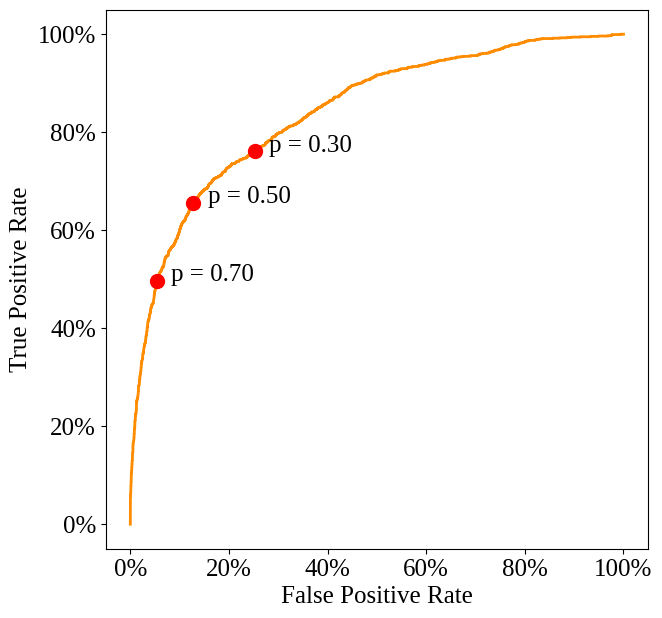

In [ ]:
# Figure 4: ROC Curves

# Load the XGB predictions csvs
mcd_predictions = pd.read_csv("xgb_mcd_predictions-YEAR-Separated.csv")

# Create a ROC curve for each classification method from the prediction scores
mcd_fpr, mcd_tpr, mcd_thresholds = metrics.roc_curve(mcd_predictions['HMTruth'], mcd_predictions['Probability'])

#true_auc = metrics.auc(true_fpr, true_tpr)
mcd_auc = metrics.auc(mcd_fpr, mcd_tpr)

#print(true_auc)
print(mcd_auc)

# Plot the ROC curves
fig1 = plt.gcf()
fig = plt.figure(figsize=(7, 7))
plt.plot(mcd_fpr, mcd_tpr, color='darkorange', lw=2, label=f'ROC curve (area = {mcd_auc:.2f})')

# Find the tpr and fpr at the same index where rounded threshold = 0.5
index_05 = np.where(np.round(mcd_thresholds, 2) == 0.5)[0][0]
mcd_tpr_05 = mcd_tpr[index_05]
mcd_fpr_05 = mcd_fpr[index_05]
print(mcd_thresholds)
print(mcd_thresholds[index_05])
# plot a marker at the tpr and fpr where threshold = 0.5, set size of marker to 100
plt.plot(mcd_fpr_05, mcd_tpr_05, 'ro', markersize=10)
# Annotate the marker with the threshold value
plt.annotate('p = ' + f'{float(mcd_thresholds[index_05]):.2f}', (mcd_fpr_05, mcd_tpr_05),
             textcoords="offset points", xytext=(40,0), ha='center')

# Find the tpr and fpr at the same index where rounded threshold = 0.7
index_08 = np.where(np.round(mcd_thresholds, 2) == 0.7)[0][0]
mcd_tpr_08 = mcd_tpr[index_08]
mcd_fpr_08 = mcd_fpr[index_08]
# plot a marker at the tpr and fpr where threshold = 0.8, set size of marker to 100
plt.plot(mcd_fpr_08, mcd_tpr_08, 'ro', markersize=10)
# Annotate the marker with the threshold value
plt.annotate('p = ' + f'{float(mcd_thresholds[index_08]):.2f}', (mcd_fpr_08, mcd_tpr_08),
             textcoords="offset points", xytext=(40,0), ha='center')

# Find the tpr and fpr at the same index where rounded threshold = 0.3
index_03 = np.where(np.round(mcd_thresholds, 2) == 0.3)[0][0]
mcd_tpr_03 = mcd_tpr[index_03]
mcd_fpr_03 = mcd_fpr[index_03]
# plot a marker at the tpr and fpr where threshold = 0.3, set size of marker to 100
plt.plot(mcd_fpr_03, mcd_tpr_03, 'ro', markersize=10)
# Annotate the marker with the threshold value
plt.annotate('p = ' + f'{float(mcd_thresholds[index_03]):.2f}', (mcd_fpr_03, mcd_tpr_03),
             textcoords="offset points", xytext=(40,0), ha='center')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Set all text to Liberation Serif
plt.rcParams['font.family'] = 'Liberation Serif'
# change the tick labels to percentage format
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x*100:.0f}%'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x*100:.0f}%'))
# set font size to 12
plt.rcParams['font.size'] = 18
plt.show()

# Save the plot
fig.savefig('roc_curves-YEAR-Separated.tif', dpi=300, bbox_inches='tight')

Pearson correlation between Probability and N2OFlux:  0.3253565028919132
P-value:  2.0892808277253334e-143
Pearson correlation between Probability and log(N2OFlux):  0.6459224743731649
P-value:  0.0


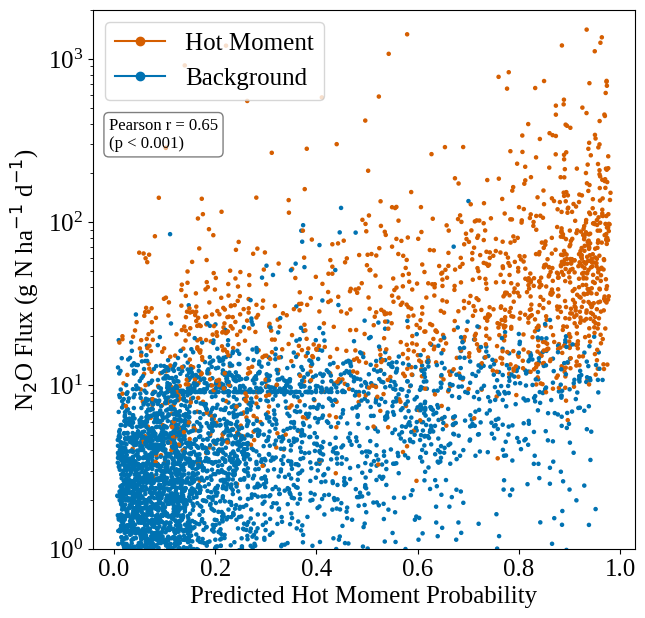

In [ ]:
# Figure 4: Scatterplot of N2OFlux vs Prediction Probability

# Load the XGB predictions csvs
true_predictions = pd.read_csv("xgb_mcd_predictions-YEAR-Separated.csv")
Y = pd.read_csv("Y_all-YEAR_SEPARATED.csv")
# add the N2OFlux column from Y to true_predictions where RawID = RawID
true_predictions = true_predictions.merge(Y, on='RawID', how='outer')

# Calculate pearson correlation between Probability and N2OFlux
corr, p_value = stats.pearsonr(true_predictions['Probability'], true_predictions['N2OFlux_y'])
print("Pearson correlation between Probability and N2OFlux: ", corr)
print("P-value: ", p_value)

# Calculate pearson correlation between Probability and the log transformed N2OFlux
# First shift N2OFlux by the lowest (negative) value + 1 to make all values positive
true_predictions['N2OFlux_y_positive'] = true_predictions['N2OFlux_y'] - true_predictions['N2OFlux_y'].min() + 1
true_predictions['log_N2OFlux'] = np.log1p(true_predictions['N2OFlux_y_positive'])
corr_log, p_value_log = stats.pearsonr(true_predictions['Probability'], true_predictions['log_N2OFlux'])
print("Pearson correlation between Probability and log(N2OFlux): ", corr_log)
print("P-value: ", p_value_log)

# Set font to Liberation Serif
plt.rcParams['font.family'] = 'Liberation Serif'
# Set font size to 12
plt.rcParams['font.size'] = 18

# Plot scatterplot of N2OFlux vs Probability, set y axis to log scale, set hue to HMTruth
fig = plt.figure(figsize=(7, 7))
cmap = ['#0072b2', '#d55e00', ]
from matplotlib.colors import ListedColormap
cmap = ListedColormap(cmap)
plt.scatter(true_predictions['Probability'], true_predictions['N2OFlux_y'],
    c=true_predictions['HMTruth_x'], s=5, alpha=1, cmap=cmap)
plt.xlabel('Predicted Hot Moment Probability')
plt.ylabel('N$_{2}$O Flux (g N ha$^{-1}$ d$^{-1}$)')
plt.yscale('log')
# Set y axis limits
plt.ylim(1, 2000)
# Add items to legend, red = Hot Moment, blue = Background, use circle markers, use seismic color map
plt.legend(handles=[plt.Line2D([0], [0], color='#d55e00', marker='o', markerfacecolor='#d55e00'),
    plt.Line2D([0], [0], color='#0072b2', marker='o', markerfacecolor='#0072b2')],
    labels=['Hot Moment', 'Background'], loc='upper left')

# Add a label to the chart with the log Pearson correlation coefficient. Set font size to 12
plt.text(0.03, 0.8, f'Pearson r = {corr_log:.2f}\n(p < 0.001)', transform=plt.gca().transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
         fontsize=12)

# Save the plot as svg
plt.savefig('N2OFlux_vs_PredictionProbability-YEAR-Separated.tif', dpi=600, bbox_inches='tight')

plt.show()

In [ ]:
import pickle
import urllib.request

# Load XGB model
filename = 'xgb_mcd_classifier_full.pkl'
xgb_classifier = pickle.load(open(filename, 'rb'))

X = pd.read_csv("X_all-YEAR_SEPARATED.csv")
X = X.drop(['RawID', 'ExperimentID', 'TreatmentID', 'Group', 'last_fert_type'], axis = 1)
Y = pd.read_csv("Y_all-YEAR_SEPARATED.csv")

In [20]:
# Ensure all columns in X are numeric (convert bool to int, and drop object columns if any)
X_numeric = X.copy()
for col in X_numeric.columns:
	if X_numeric[col].dtype == bool:
		X_numeric[col] = X_numeric[col].astype(int)
	elif X_numeric[col].dtype == object:
		# Try to convert to numeric, if fails, drop the column
		try:
			X_numeric[col] = pd.to_numeric(X_numeric[col])
		except Exception:
			X_numeric = X_numeric.drop(columns=[col])

# build a clustering of the features based on shared information about y
#clustering = shap.utils.hclust(X_numeric, Y['HMTruth'])

# above we implicitly used shap.maskers.Independent by passing a raw dataframe as the masker
# now we explicitly use a Partition masker that uses the clustering we just computed
#masker = shap.maskers.Partition(X_numeric, clustering=clustering)

# build an Exact explainer and explain the model predictions on the given dataset
explainer = shap.explainers.TreeExplainer(xgb_classifier)
shap_values2 = explainer(X_numeric)

In [21]:
import pickle
# Save  shap values
with open('xgb_mcd_shap_values.pkl', 'wb') as f:
    pickle.dump(shap_values2, f)

In [36]:
# Load shap values
import shap
import pickle
with open('xgb_mcd_shap_values.pkl', 'rb') as f:
    shap_values2 = pickle.load(f)

/tmp/ipykernel_1742/4071094538.py:24: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



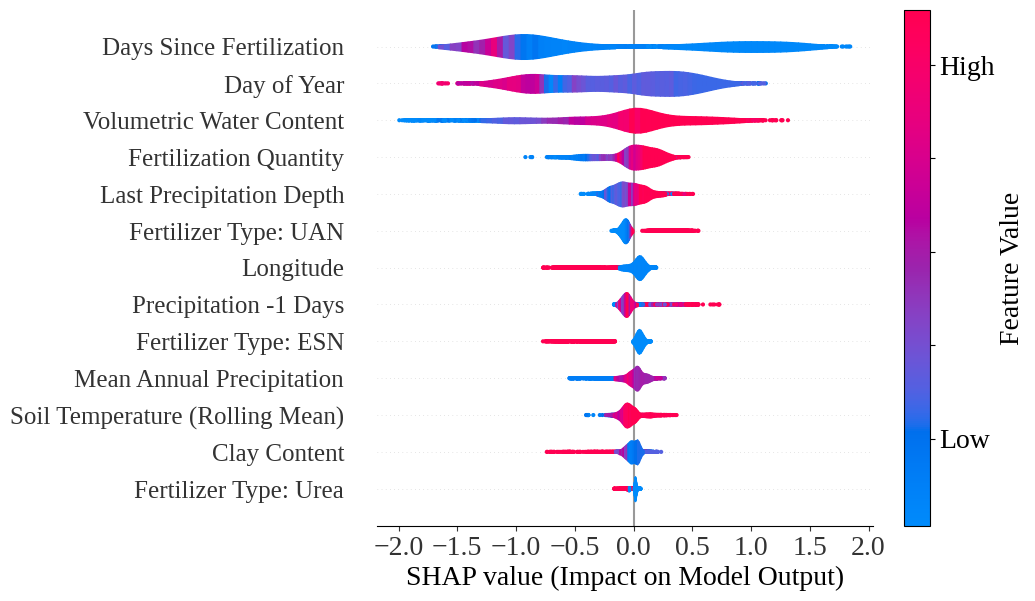

In [ ]:
# Figure 5: SHAP Violin Plot

main_features = [0, 1, 6, 7, 10, 13, 14, 15, 23, 38, 44, 46, 48]
feat_names = ['Day of Year', 'Volumetric Water Content',
              'Clay Content', 'Mean Annual Precipitation',
              'Longitude', 'Last Precipitation Depth',
              'Days Since Fertilization',
              'Fertilization Quantity', 'Precipitation -1 Days',
              'Soil Temperature (Rolling Mean)',
              'Fertilizer Type: ESN', 'Fertilizer Type: UAN',
              'Fertilizer Type: Urea']
shap.plots.violin(shap_values2[:,main_features], max_display=16,  show=False, feature_names=feat_names, color_bar=False)
# Set tick label font
plt.rc('font', family='Liberation Serif')
# Set x axis font size
plt.xticks(fontsize=20)
plt.xlabel(xlabel='SHAP value (Impact on Model Output)', fontsize=20)

# Set y axis font size
plt.yticks(fontsize=18)

# Set shap color bar font
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=20)
##### Set cbar tick labels
cbar.ax.set_yticklabels(['','Low', '','','', 'High'])

# Set colorbar labels
cbar.ax.set_ylabel('Feature Value', fontsize=20)
# Set font to Times New Roman
plt.rc('font', family='Liberation Serif')


plt.savefig('all_shap_violin.png', bbox_inches = 'tight', pad_inches = 0.1, dpi = 800)

In [ ]:
# Data engineering for Figure 6: VWC and Days Since Fertilization Hot Moment Percentage Heatmap

# Load X and Y data
true_predictions = pd.read_csv("xgb_true_predictions-YEAR-Separated.csv")
X = pd.read_csv("X_plus-YEAR_SEPARATED.csv")
# Connect to mysql database
cnx = mysql.connector.connect(user='root', password='Kh18riku!',
                                host='127.0.0.1',
                                database='global_n2o')
cursor = cnx.cursor()

query = ("SELECT * FROM RawClassificationTreatment")

# Execute the query and fetch all results
alldata = pd.read_sql(query, cnx)
cnx.close()
alldata = pd.merge(true_predictions, alldata[['RawID', 'N2OFlux', 'VWC', 'SoilT']], on='RawID')
alldata = pd.merge(alldata, X[['RawID', 'days_since_fert']], on='RawID')
print(alldata.head())

# Create for both VWC and Days Since Fertilization. Find the percent of hot moments in the intersection of each bin
vwc_bin_edges = np.arange(0.05, 0.56, 0.05)
vwc_bin_centers = vwc_bin_edges[:-1] + 0.05
fert_bin_edges = np.arange(0, 81, 10)
fert_bin_centers = fert_bin_edges[:-1] + 5
vwc_fert_df = pd.DataFrame(columns=['VWC', 'DaysSinceFert', 'HM_Percentage', 'n'])
for i in np.arange(len(vwc_bin_centers)):
    for j in np.arange(len(fert_bin_centers)):
        hm = len(alldata.query('VWC >= @vwc_bin_edges[@i] and VWC < @vwc_bin_edges[@i+1] and days_since_fert >= @fert_bin_edges[@j] and days_since_fert < @fert_bin_edges[@j+1] and Prediction == 1'))
        total = len(alldata.query('VWC >= @vwc_bin_edges[@i] and VWC < @vwc_bin_edges[@i+1] and days_since_fert >= @fert_bin_edges[@j] and days_since_fert < @fert_bin_edges[@j+1]'))
        if total == 0:
            new_row = pd.DataFrame([{'VWC': vwc_bin_centers[i], 'DaysSinceFert': fert_bin_centers[j], 'HM_Percentage': -0.1, 'n': ' '}])
            vwc_fert_df = pd.concat([vwc_fert_df, new_row], ignore_index=True)

        else:
            new_row = pd.DataFrame([{'VWC': vwc_bin_centers[i], 'DaysSinceFert': fert_bin_centers[j], 'HM_Percentage': hm / total,
                                      'n': total}])
            vwc_fert_df = pd.concat([vwc_fert_df, new_row], ignore_index=True)

# Save df
vwc_fert_df.to_csv("vwc_fert_df.csv", index=False)

/tmp/ipykernel_1598933/3488060019.py:13: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



   RawID  TreatmentID  HMTruth  Prediction  N2OFlux_x  N2OFlux_y      VWC  \
0   4960           25      0.0           0      9.715      9.715  0.35475   
1   4974           25      0.0           1     11.845     11.845  0.32675   
2   5155           25      0.0           0      9.970      9.970  0.17900   
3   5169           25      0.0           0      9.340      9.340  0.19475   
4   5317           25      0.0           0      9.120      9.120  0.40475   

    SoilT  days_since_fert  
0   8.725            726.0  
1  15.475              6.0  
2   2.825            187.0  
3   3.175            201.0  
4   4.900            349.0  


/tmp/ipykernel_1598933/3488060019.py:36: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [ ]:
# Data engineering for Figure 6: VWC and Soil Temperature Hot Moment Percentage Heatmap

# Load X and Y data
true_predictions = pd.read_csv("xgb_true_predictions-YEAR-Separated.csv")
# Connect to mysql database
cnx = mysql.connector.connect(user='root', password='Kh18riku!',
                                host='127.0.0.1',
                                database='global_n2o')
cursor = cnx.cursor()

query = ("SELECT * FROM RawClassificationTreatment")
# Execute the query and fetch all results
alldata = pd.read_sql(query, cnx)
cnx.close()
alldata = pd.merge(true_predictions, alldata[['RawID', 'N2OFlux', 'VWC', 'SoilT']], on='RawID')
print(alldata.head())

# Create for both VWC and SoilT. Find the percent of hot moments in the intersection of each bin
vwc_bin_edges = np.arange(0.05, 0.56, 0.05)
vwc_bin_centers = vwc_bin_edges[:-1] + 0.05
soilT_bin_edges = np.arange(0, 31, 5)
soilT_bin_centers = soilT_bin_edges[:-1] + 2.5
vwc_soilT_df = pd.DataFrame(columns=['VWC', 'SoilT', 'HM_Percentage', 'n'])
print(np.arange(len(soilT_bin_centers) - 1))
for i in np.arange(len(vwc_bin_edges) - 1):
    for j in np.arange(len(soilT_bin_edges) - 1):
        hm = len(alldata.query('VWC >= @vwc_bin_edges[@i] and VWC < @vwc_bin_edges[@i+1] and SoilT >= @soilT_bin_edges[@j] and SoilT < @soilT_bin_edges[@j+1] and Prediction == 1'))
        total = len(alldata.query('VWC >= @vwc_bin_edges[@i] and VWC < @vwc_bin_edges[@i+1] and SoilT >= @soilT_bin_edges[@j] and SoilT < @soilT_bin_edges[@j+1]'))
        if total == 0:
            new_row = pd.DataFrame([{'VWC': vwc_bin_centers[i], 'SoilT': soilT_bin_centers[j], 'HM_Percentage': -0.1, 'n': ' '}])
            vwc_soilT_df = pd.concat([vwc_soilT_df, new_row], ignore_index=True)
        else:
            new_row = pd.DataFrame([{'VWC': vwc_bin_centers[i], 'SoilT': soilT_bin_centers[j], 'HM_Percentage': hm / total,
                                      'n': total}])
            vwc_soilT_df = pd.concat([vwc_soilT_df, new_row], ignore_index=True)

# Save df
vwc_soilT_df.to_csv("vwc_soilT_df.csv", index=False)

# Load X and Y data
true_predictions = pd.read_csv("xgb_true_predictions-YEAR-Separated.csv")


# Connect to mysql database
cnx = mysql.connector.connect(user='root', password='Kh18riku!',
                                host='127.0.0.1',
                                database='global_n2o')
cursor = cnx.cursor()

query = ("SELECT * FROM RawClassificationTreatment")
# Execute the query and fetch all results
alldata = pd.read_sql(query, cnx)
cnx.close()
alldata = pd.merge(true_predictions, alldata[['RawID', 'N2OFlux', 'VWC', 'SoilT']], on='RawID')
print(alldata.head())

# Create for both VWC and SoilT. Find the percent of hot moments in the intersection of each bin
vwc_bin_edges = np.arange(0.05, 0.56, 0.05)
vwc_bin_centers = vwc_bin_edges[:-1] + 0.05
soilT_bin_edges = np.arange(0, 31, 5)
soilT_bin_centers = soilT_bin_edges[:-1] + 2.5
vwc_soilT_df = pd.DataFrame(columns=['VWC', 'SoilT', 'HM_Percentage', 'n'])
print(np.arange(len(soilT_bin_centers) - 1))
for i in np.arange(len(vwc_bin_edges) - 1):
    for j in np.arange(len(soilT_bin_edges) - 1):
        hm = len(alldata.query('VWC >= @vwc_bin_edges[@i] and VWC < @vwc_bin_edges[@i+1] and SoilT >= @soilT_bin_edges[@j] and SoilT < @soilT_bin_edges[@j+1] and Prediction == 1'))
        total = len(alldata.query('VWC >= @vwc_bin_edges[@i] and VWC < @vwc_bin_edges[@i+1] and SoilT >= @soilT_bin_edges[@j] and SoilT < @soilT_bin_edges[@j+1]'))
        if total == 0:
            new_row = pd.DataFrame([{'VWC': vwc_bin_centers[i], 'SoilT': soilT_bin_centers[j], 'HM_Percentage': -0.1, 'n': ' '}])
            vwc_soilT_df = pd.concat([vwc_soilT_df, new_row], ignore_index=True)
        else:
            new_row = pd.DataFrame([{'VWC': vwc_bin_centers[i], 'SoilT': soilT_bin_centers[j], 'HM_Percentage': hm / total,
                                      'n': total}])
            vwc_soilT_df = pd.concat([vwc_soilT_df, new_row], ignore_index=True)

# Save df
vwc_soilT_df.to_csv("vwc_soilT_df.csv", index=False)# Load X and Y data


/tmp/ipykernel_1598933/180190101.py:11: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



   RawID  TreatmentID  HMTruth  Prediction  N2OFlux_x  N2OFlux_y      VWC  \
0   4960           25      0.0           0      9.715      9.715  0.35475   
1   4974           25      0.0           1     11.845     11.845  0.32675   
2   5155           25      0.0           0      9.970      9.970  0.17900   
3   5169           25      0.0           0      9.340      9.340  0.19475   
4   5317           25      0.0           0      9.120      9.120  0.40475   

    SoilT  
0   8.725  
1  15.475  
2   2.825  
3   3.175  
4   4.900  
[0 1 2 3 4]


/tmp/ipykernel_1598933/180190101.py:33: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_1598933/180190101.py:50: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



   RawID  TreatmentID  HMTruth  Prediction  N2OFlux_x  N2OFlux_y      VWC  \
0   4960           25      0.0           0      9.715      9.715  0.35475   
1   4974           25      0.0           1     11.845     11.845  0.32675   
2   5155           25      0.0           0      9.970      9.970  0.17900   
3   5169           25      0.0           0      9.340      9.340  0.19475   
4   5317           25      0.0           0      9.120      9.120  0.40475   

    SoilT  
0   8.725  
1  15.475  
2   2.825  
3   3.175  
4   4.900  
[0 1 2 3 4]


/tmp/ipykernel_1598933/180190101.py:72: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [ ]:
# Data engineering for Figure 6: Days Since Fertilization and Fertilizer Type Hot Moment Percentage Heatmap

# Load X
X = pd.read_csv("X_plus-YEAR_SEPARATED.csv")
# Load true predictions
true_predictions = pd.read_csv("xgb_true_predictions-YEAR-Separated.csv")
# Merge X with predictions
alldata = pd.merge(true_predictions, X, on='RawID')
# Drop rows where Prediction is null
alldata = alldata.dropna(subset=['Prediction'])
# Rename 'Ammonia'  to 'Anhydrous Ammonia'
alldata['last_fert_type'] = alldata['last_fert_type'].replace('Ammonia', 'Anhydrous Ammonia')

# Create bins for days since fert
days_since_fert_bin_edges = np.arange(0, 81, 10)
days_since_fert_bin_centers = days_since_fert_bin_edges[:-1] + 5
fert_model_df = pd.DataFrame(columns=['DaysSinceFert', 'FertType' , 'HM_Percentage', 'n'])

# For each unique value in LastFertType whith value count above 1000, iterate through each bin of days since fert and calculate the HM_Percentage
# Rename 'Ammonia' and 'Ammonium Phosphate' to 'Ammonium'
f_types = alldata['last_fert_type'].value_counts()
print(f_types)

f_types = f_types.index
for f_type in f_types:
    for i in np.arange(len(days_since_fert_bin_edges) - 1):
        hm = len(alldata.query('last_fert_type == @f_type and days_since_fert >= @days_since_fert_bin_edges[@i] and days_since_fert < @days_since_fert_bin_edges[@i+1] and Prediction == 1'))
        total = len(alldata.query('last_fert_type == @f_type and days_since_fert >= @days_since_fert_bin_edges[@i] and days_since_fert < @days_since_fert_bin_edges[@i+1]'))
        if total == 0:
            new_row = pd.DataFrame([{'DaysSinceFert': days_since_fert_bin_centers[i], 'FertType': f_type, 'HM_Percentage': -0.1, 'n': ' '}])
            fert_model_df = pd.concat([fert_model_df, new_row], ignore_index=True)
     
        else:
            new_row = pd.DataFrame([{'DaysSinceFert': days_since_fert_bin_centers[i], 'FertType': f_type, 'HM_Percentage': hm / total,
                                      'n': total}])
            fert_model_df = pd.concat([fert_model_df, new_row], ignore_index=True)

# Save df
fert_model_df.to_csv("fert_model_df.csv", index=False)

last_fert_type
Urea                  1869
UAN                   1084
ESN                    869
Unknown                790
Manure                 379
Anhydrous Ammonia      320
Ammonium Nitrate       261
Ammonium Phosphate     183
Cover Crop              58
Name: count, dtype: int64


/tmp/ipykernel_1598933/139372619.py:34: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [ ]:
# Figure 6: VWC and Days Since Fertilization Hot Moment Percentage Heatmap

from plotly.subplots import make_subplots
import plotly.graph_objects as go
# Load df
vwc_fert_df = pd.read_csv("vwc_fert_df.csv")
vwc_fert_df['HM_Percentage'] = vwc_fert_df['HM_Percentage'].astype(float) * 100
vwc_soilT_df = pd.read_csv("vwc_soilT_df.csv")

fert_model_df = pd.read_csv("fert_model_df.csv")
# Drop unknown fert types
fert_model_df = fert_model_df.query('FertType != "Unknown"')
fert_model_df = fert_model_df.query('FertType != "Unknown"')

# Set all font to Liberation Serif
plt.rcParams['font.family'] = 'Liberation Serif'

# Order a list of fert type by the overall average HM_Percentage
fert_types = fert_model_df['FertType'].unique()
fert_type_avg = []
for f_type in fert_types:
    avg = statistics.mean(fert_model_df.query('FertType == @f_type')['HM_Percentage'])
    fert_type_avg.append(avg)
fert_type_avg, fert_types = zip(*sorted(zip(fert_type_avg, fert_types)))
fert_types = list(fert_types)

vwc_soilT_df['HM_Percentage'] = vwc_soilT_df['HM_Percentage'].astype(float) * 100
fert_model_df['HM_Percentage'] = fert_model_df['HM_Percentage'].astype(float) * 100

# Create a 2 by 2 grid of subplots
fig = make_subplots(rows=2, cols=2, vertical_spacing=0.03, horizontal_spacing=0.01)

# Create a heatmap of HM_Percentage vs VWC and DaysSinceFert in the top left subplot
p1 = go.Heatmap(x=vwc_fert_df['VWC'], y=vwc_fert_df['DaysSinceFert'], z=vwc_fert_df['HM_Percentage'], zmin=-10, zmax=100, colorscale=[
    'rgb(255, 255, 255)', 'rgb(0, 0, 150)', 'rgb(25, 0, 200)', 'rgb(50, 0, 250)', 'rgb(75, 0, 200)', 'rgb(100, 0, 150)',
    'rgb(125, 0, 125)', 'rgb(170, 0, 100)', 'rgb(225, 0, 50)', 'rgb(255, 0, 0)', 'rgb(225, 0, 0)', 'rgb(150, 0, 0)'], colorbar={'title': 'Predicted<br>Probability of<br>Hot Moment (%)'}, text=vwc_fert_df['n'], textfont=dict(size=10), texttemplate="%{text}")

fig.append_trace(p1,1,1)
fig.update_layout(width=800, height=800)

# Label axis
fig.update_xaxes(title_text='Volumetric Water Content', row=2, col=1)
fig.update_xaxes(title_text='', row=1, col=1)

fig.update_yaxes(title_text='Days Since Fertilization', row=1, col=1)
fig.update_yaxes(title_text='Soil Temperature (°C)', row=2, col=1)

# Update font
fig.update_layout(font=dict(
        family="Times New Roman",
        size=20,
        color="Black"
    ))
# Y axis labels in increments of 10
fig.update_yaxes(tickvals=[0, 10, 20, 30, 40, 50, 60, 70, 80, ], ticktext=['0', '10', '20', '30', '40', '50', '60', '70', '80',])
# Reverse order of y axis
#fig.update_yaxes(autorange="reversed", row=1, col=1)

# Convert x axis labels to percent
fig.update_xaxes(tickvals=[0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, ], ticktext=['5%', '5-10%', '10-15%', '15-20%', '20-25%',
                                                                                                  '25-30%', '30-35%', '35-40%', '40-45%', '45-50%',
                                                                                                  '50-55%'], tickangle=90, row=2, col=1)
fig.update_xaxes(tickvals=[0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, ], ticktext=['', '', '', '', '',
                                                                                                  '', '', '', '', '',
                                                                                                  ''], row=1, col=1)
p2 = go.Heatmap(x=vwc_soilT_df['VWC'], y=vwc_soilT_df['SoilT'], z=vwc_soilT_df['HM_Percentage'], zmin=-10, zmax=100, colorscale=[
    'rgb(255, 255, 255)', 'rgb(0, 0, 150)', 'rgb(25, 0, 200)', 'rgb(50, 0, 250)', 'rgb(75, 0, 200)', 'rgb(100, 0, 150)',
    'rgb(125, 0, 125)', 'rgb(170, 0, 100)', 'rgb(225, 0, 50)', 'rgb(255, 0, 0)', 'rgb(225, 0, 0)', 'rgb(150, 0, 0)'], colorbar={'title': 'Predicted<br>Probability of<br>Hot Moment (%)'}, text=vwc_soilT_df['n'], textfont=dict(size=10), texttemplate="%{text}")

fig.append_trace(p2,2,1)
fig.update_yaxes(tickvals=[0, 5, 10, 15, 20, 25, 30,], ticktext=['0', '5', '10', '15', '20', '25', '30'], row=2, col=1)

# Create a heatmap of HM_Percentage vs DaysSinceFert and FertType
p3 = go.Heatmap(y=fert_model_df['DaysSinceFert'], x=fert_model_df['FertType'], z=fert_model_df['HM_Percentage'], zmin=-10, zmax=100, colorscale=[
    'rgb(255, 255, 255)', 'rgb(0, 0, 150)', 'rgb(25, 0, 200)', 'rgb(50, 0, 250)', 'rgb(75, 0, 200)', 'rgb(100, 0, 150)',
    'rgb(125, 0, 125)', 'rgb(170, 0, 100)', 'rgb(225, 0, 50)', 'rgb(255, 0, 0)', 'rgb(225, 0, 0)', 'rgb(150, 0, 0)'], colorbar={'title': 'Predicted<br>Probability of<br>Hot Moment (%)'}, text=fert_model_df['n'], textfont=dict(size=10), texttemplate="%{text}")

fig.update_yaxes(tickvals=[0, 10, 20, 30, 40, 50, 60, 70, 80, ], ticktext=['', '', '', '', '',
                                                                                                  '', '', '', '', '',
                                                                                                  ''], row=1, col=2)
# Set x lim
fig.update_xaxes(range=[0.075, .525], row=1, col=1)
fig.update_xaxes(range=[0.075, .525], row=2, col=1)

fig.append_trace(p3,1,2)
#fig.update_yaxes(autorange="reversed", row=1, col=2)
fig.update_xaxes(tickangle=90, row=1, col=2)


# Set padding
fig.update_layout(margin=dict(l=1, r=1, t=1, b=1))
# Set font
fig.update_layout(font=dict(
        family="Times New Roman",
        size=20,
        color="Black"
    ))

# Set font to Liberation Serif
plt.rcParams['font.family'] = 'Liberation Serif'


fig.show()
# Save fig
fig.write_image("vwc_fert_heatmap.png", format='png')

TypeError: write_image() got an unexpected keyword argument 'dpi'